# NHS data analysis

In [ ]:
# Business statement
Investigate focus on variations in appointment volumes across regions and time in order to identify demand trends, optimise resource allocation, and improve service efficiency in healthcare delivery.

# Objectives 
Identifiable seasonal trends.
Analyse regional differences in healthcare service usage.
Use of appointment data to improve healthcare service planning and reduce system strain.

In [ ]:
# Approch
Clean data
Check distributions
Time trends
Geographic comparison
Efficiency (duration vs volume)

# Finding answers
Which regions handle the most appointments?
Are appointments increasing or decreasing over time?
Which locations are most/least efficient (duration vs volume)?
Are there extreme outliers (data issues or real spikes)?
Do certain areas have consistently longer appointment durations?

pip install wordcloud

In [1]:
# Import the necessary libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

# Actual_duration

In [4]:
# Import data set as ad.
ad = pd.read_csv('actual_duration.csv')
ad.head(5)

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730


In [4]:
ad.columns

Index(['sub_icb_location_code', 'sub_icb_location_ons_code',
       'sub_icb_location_name', 'icb_ons_code', 'region_ons_code',
       'appointment_date', 'actual_duration', 'count_of_appointments'],
      dtype='object')

In [5]:
ad.dtypes

sub_icb_location_code        object
sub_icb_location_ons_code    object
sub_icb_location_name        object
icb_ons_code                 object
region_ons_code              object
appointment_date             object
actual_duration              object
count_of_appointments         int64
dtype: object

In [6]:
ad.shape

(137793, 8)

In [6]:
# missing values.
ad.isnull().sum()

sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
appointment_date             0
actual_duration              0
count_of_appointments        0
dtype: int64

In [7]:
# unique locations
ad['sub_icb_location_name'].nunique()

106

In [43]:
# check for duplicates
ad.duplicated().sum()

0

In [9]:
# descriptive statistics 
ad.describe()

,count_of_appointments
count,137793.000000
mean,1219.080011
std,1546.902956
min,1.000000
25%,194.000000
50%,696.000000
75%,1621.000000
max,15400.000000


In [3]:
# total num appointments
ad['count_of_appointments'].sum()

167980692

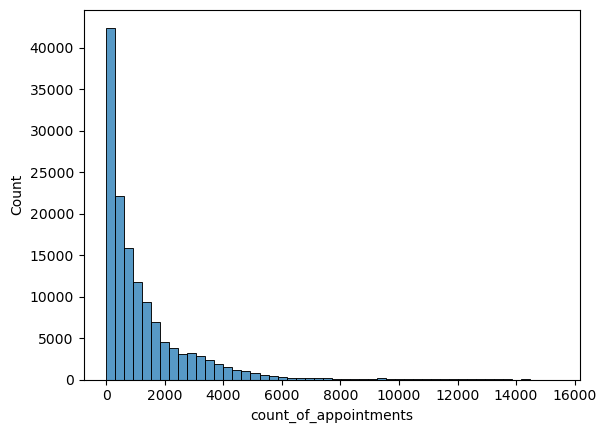

In [5]:
# appointment distribution
sns.histplot(ad['count_of_appointments'], bins=50)
plt.show()

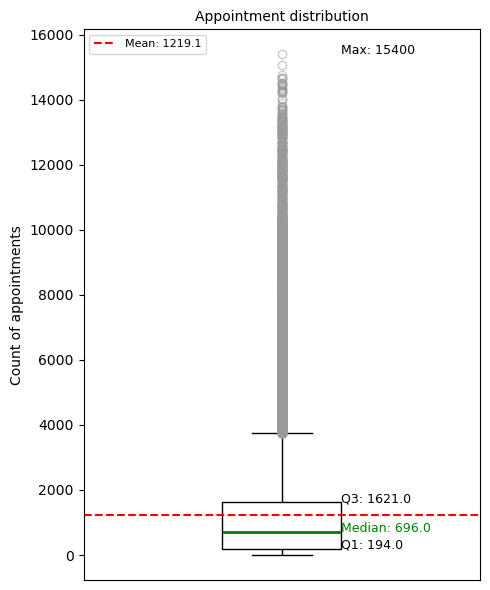

In [6]:
# data
appointments = ad['count_of_appointments']

# stats
mean_appt = appointments.mean()
median = appointments.median()
q1 = appointments.quantile(0.25)
q3 = appointments.quantile(0.75)
_min = appointments.min()
_max = appointments.max()

plt.figure(figsize=(5,6))

# box plot - unfilled
sns.boxplot(
    y=appointments,
    color='white',
    width=0.3,
    boxprops=dict(edgecolor='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='green', linewidth=2),
    flierprops=dict(marker='o', color='blue', alpha=0.5)
)

# annotate with offsets to avoid overlapping
#plt.text(0.15, _min, f"Min: {_min}", fontsize=9, ha='left')
plt.text(0.15, q1, f"Q1: {q1:.1f}", fontsize=9, ha='left')
plt.text(0.15, median, f"Median: {median:.1f}", fontsize=9, color='green', ha='left')
plt.text(0.15, q3, f"Q3: {q3:.1f}", fontsize=9, ha='left')
plt.text(0.15, _max, f"Max: {_max}", fontsize=9, ha='left')
plt.axhline(mean_appt, color='red', linestyle='--', label=f"Mean: {mean_appt:.1f}")

# formatting
plt.ylabel('Count of appointments')
plt.xticks([])
plt.title('Appointment distribution', fontsize=10)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [18]:
#check data types
ad.dtypes

sub_icb_location_code        object
sub_icb_location_ons_code    object
sub_icb_location_name        object
icb_ons_code                 object
region_ons_code              object
appointment_date             object
actual_duration              object
count_of_appointments         int64
dtype: object

In [8]:
# convert apponitment_date to datetime
ad['appointment_date'] = pd.to_datetime(ad['appointment_date'], format = '%d-%b-%y')

In [9]:
# monthly counts
monthly_counts = (
     ad
    .groupby([ad['appointment_date'].dt.to_period('M'), 'actual_duration'])['count_of_appointments'] 
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
monthly_counts

# percentage of actual duration appointment counts
monthly_counts ['perc_appointments'] = (monthly_counts['count_of_appointments'] * 100 / monthly_counts['count_of_appointments']
                                        .sum()).round(2)
monthly_counts

,appointment_date,actual_duration,count_of_appointments,perc_appointments
0,2022-03,Unknown / Data Quality,6472072,3.85
1,2022-05,Unknown / Data Quality,6059540,3.61
2,2022-06,Unknown / Data Quality,5676225,3.38
3,2022-01,Unknown / Data Quality,5627141,3.35
4,2022-02,Unknown / Data Quality,5588440,3.33
5,2021-12,Unknown / Data Quality,5579512,3.32
6,2022-03,6-10 Minutes,5489184,3.27
7,2022-04,Unknown / Data Quality,5281156,3.14
8,2022-05,6-10 Minutes,5033645,3.00
9,2022-01,6-10 Minutes,4778719,2.84


The Actual Duration (ad) dataset contains information about patients’ appointment durations and location details. Also,a substantial portion of appointments in both 2021 and 2022 are labeled as “Unknown” or have a data quality issue, accounting for 20.66% and 3.32% respectively. This indicates potential problems with data recording or missing information.

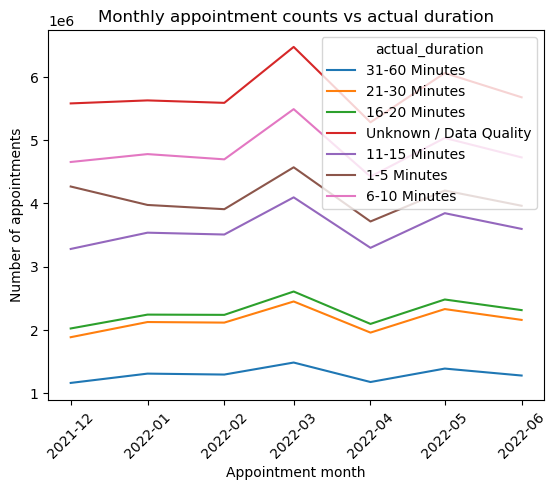

In [10]:
# convert to timestamp for plotting
monthly_counts['month'] = monthly_counts['appointment_date'].dt.to_timestamp()

# plot
sns.lineplot(
    data=monthly_counts.sort_values(by='month'),
    x='month', y='count_of_appointments', hue='actual_duration'
)
plt.xlabel('Appointment month')
plt.ylim()
plt.ylabel('Number of appointments')
plt.title('Monthly appointment counts vs actual duration')
plt.xticks(rotation=45)
plt.show()

In [ ]:
The most common type of appointment is 6-10 Minutes and 1-5 Minutes.
A significant number of appointments fall under Unknown data quality, indicating either missing data or unclear recording.
Appointments lasting 16-20, 21-30 and 31-60 Minutes occur less frequent.
The contribution of appointments across duration categories remains fairly consistent,3.8-0.7% per month.
There is sharp increase of appointmnets in March, 2022.

In [11]:
# yearly appointments
yearly_counts = (
    ad
    .groupby([ad['appointment_date'].dt.to_period('y'), 'actual_duration'])['count_of_appointments'] 
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
yearly_counts

# percentage of actual duration appointment counts yearly
yearly_counts ['perc_appointments'] = (yearly_counts['count_of_appointments'] * 100 / yearly_counts['count_of_appointments']
                                       .sum()).round(2)
yearly_counts

,appointment_date,actual_duration,count_of_appointments,perc_appointments
0,2022,Unknown / Data Quality,34704574,20.66
1,2022,6-10 Minutes,29146815,17.35
2,2022,1-5 Minutes,24334179,14.49
3,2022,11-15 Minutes,21880750,13.03
4,2022,16-20 Minutes,13980473,8.32
5,2022,21-30 Minutes,13140501,7.82
6,2022,31-60 Minutes,7939917,4.73
7,2021,Unknown / Data Quality,5579512,3.32
8,2021,6-10 Minutes,4654000,2.77
9,2021,1-5 Minutes,4266686,2.54


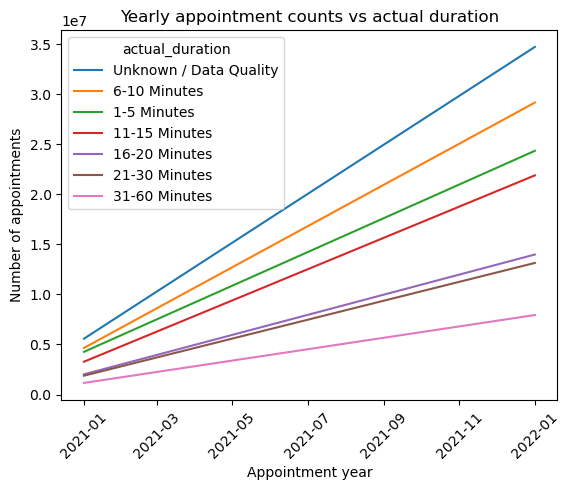

In [12]:
# convert to time stamp for plotting
yearly_counts['year'] = yearly_counts['appointment_date'].dt.to_timestamp()
sns.lineplot(
    data=yearly_counts.sort_values(by='year'),
    x='year', y='count_of_appointments', hue='actual_duration'
)
plt.xlabel('Appointment year')
plt.ylim()
plt.ylabel('Number of appointments')
plt.title('Yearly appointment counts vs actual duration')
plt.xticks(rotation=45)
plt.show()

In [ ]:
A significant portion of appointments in both years, 2021 and 2022 have an Unknown: 20.66% and 3.32% respectively.
This suggests data recording issues or missing information.
 •	In both years, the most common recorded durations are 6-10 Minutes and 1-5 Minutes, 
together accounting for over 30% of all appointments in 2022.
 •	Appointments over 20 minutes (21-30 Minutes and 31-60 Minutes) are less frequent, together making up less than 13% of appointments in 2022.

Year-on-year trend
The majority of appointments are relatively short (under 15 minutes).
 Nuumber of appointments increases in 2022, which could be due to a variety of factors:post-pandemic catch-up, improvements in recording data.

In [13]:
# trends in actual duration category
actual_duration = (
    ad.groupby('actual_duration')['count_of_appointments']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)
# percentage of actual duration appointment counts
actual_duration['perc_appointments'] = (actual_duration['count_of_appointments'] * 100 / actual_duration['count_of_appointments']
                                        .sum()).round(2)
actual_duration

,actual_duration,count_of_appointments,perc_appointments
0,Unknown / Data Quality,40284086,23.98
1,6-10 Minutes,33800815,20.12
2,1-5 Minutes,28600865,17.03
3,11-15 Minutes,25160882,14.98
4,16-20 Minutes,16004247,9.53
5,21-30 Minutes,15026365,8.95
6,31-60 Minutes,9103432,5.42


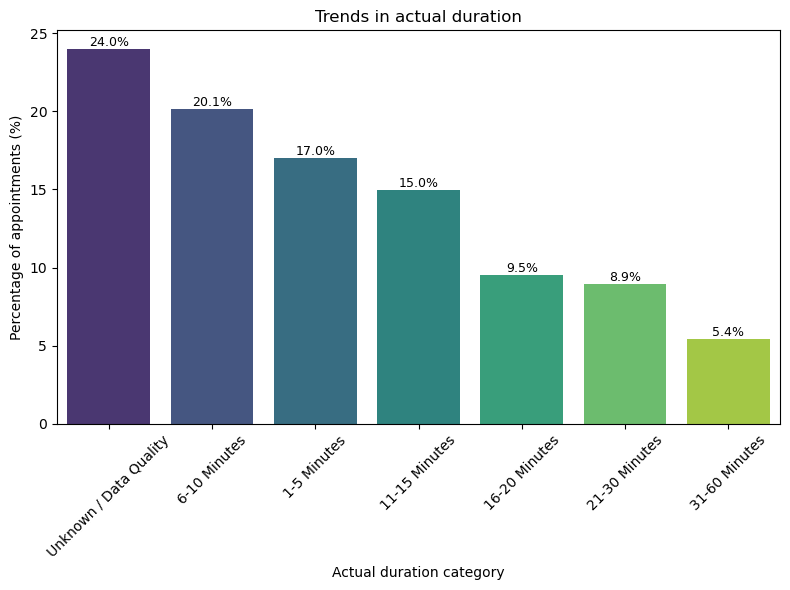

In [21]:
# plot actual duration
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=actual_duration, 
    y='perc_appointments', 
    x='actual_duration', 
    hue='actual_duration',
    palette='viridis'
)

plt.xticks(rotation=45)
plt.title('Trends in actual duration')
plt.xlabel('Actual duration category')
plt.ylabel('Percentage of appointments (%)')

# annotate bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9)

#plt.legend().remove()  # optional: removes redundant legend
plt.tight_layout()
plt.show()

The majority of appointments (over 50%) last 15 minutes or less.
Longer Appointments(20 min or more) are only 14% of total appointments
6-10 Minutes is the Most common recorded duration. This category alone makes up about one-fifth of all appointments.

Conclusion:
Most appointments are short, with a significant portion of data lacking accurate recording. 
Improving data quality will enhance future analysis and service planning. eg: Nearly a quarter of appointments have unknown or poor-quality in duration data.

In [22]:
# sub regions handle the most appointments?
sub_region_counts =ad.groupby('sub_icb_location_name')['count_of_appointments'].sum().sort_values(ascending = False).reset_index()
sub_region_counts

,sub_icb_location_name,count_of_appointments
0,NHS North West London ICB - W2U3Z,6976986
1,NHS North East London ICB - A3A8R,5341883
2,NHS Kent and Medway ICB - 91Q,5209641
3,NHS Hampshire and Isle Of Wight ICB - D9Y0V,4712737
4,NHS South East London ICB - 72Q,4360079
...,...,...
101,NHS Greater Manchester ICB - 00V,362242
102,NHS Cheshire and Merseyside ICB - 01V,358060
103,NHS Cheshire and Merseyside ICB - 01F,348396
104,NHS Cheshire and Merseyside ICB - 01T,340895


In [23]:
# least busiest NHS locations
sub_region_counts.tail(2)

,sub_icb_location_name,count_of_appointments
104,NHS Cheshire and Merseyside ICB - 01T,340895
105,NHS Lancashire and South Cumbria ICB - 02G,311713


NHS North West London ICB recorded the highest number of appointments while NHS Lancashire and South Cumbria ICB recorded lowest number of appointments.

In [29]:
# region counts
region_counts = ad.groupby('region_ons_code')['count_of_appointments'].sum().sort_values(ascending = False)
region_counts

region_ons_code
E40000011    32574555
E40000012    27425610
E40000005    25577953
E40000003    24488519
E40000010    19880924
E40000007    19546694
E40000006    18486437
Name: count_of_appointments, dtype: int64

In [36]:
ad.loc[ad['region_ons_code'] == 'E40000011', 'sub_icb_location_name'].unique()

array(['NHS Nottingham and Nottinghamshire ICB - 02Q',
       'NHS Leicester Leicestershire and Rutland ICB - 03W',
       'NHS Leicester Leicestershire and Rutland ICB - 04C',
       'NHS Leicester Leicestershire and Rutland ICB - 04V',
       'NHS Staffordshire and Stoke-on-Trent ICB - 04Y',
       'NHS Staffordshire and Stoke-on-Trent ICB - 05D',
       'NHS Staffordshire and Stoke-on-Trent ICB - 05G',
       'NHS Staffordshire and Stoke-on-Trent ICB - 05Q',
       'NHS Staffordshire and Stoke-on-Trent ICB - 05V',
       'NHS Staffordshire and Stoke-on-Trent ICB - 05W',
       'NHS Birmingham and Solihull ICB - 15E',
       'NHS Derby and Derbyshire ICB - 15M',
       'NHS Herefordshire and Worcestershire ICB - 18C',
       'NHS Nottingham and Nottinghamshire ICB - 52R',
       'NHS Lincolnshire ICB - 71E', 'NHS Northamptonshire ICB - 78H',
       'NHS Coventry and Warwickshire ICB - B2M3M',
       'NHS Black Country ICB - D2P2L',
       'NHS Shropshire Telford and Wrekin ICB - M2L0

In [37]:
ad.loc[ad['region_ons_code'] == 'E40000011', 'count_of_appointments'].sum()

32574555

The highest number of appointments was recorded in region E40000011,
covering 18 sub-ICB locations, with a total of 32,574,555 appointments.

This suggests it is the busiest region in terms of service demand compared with other regions. NHS North East and North Cumbria ICB and NHS Sussex ICB, recorded lower appointment volumes.

# Regional appointment data

In [38]:
# load regional appointment data
ar = pd.read_csv('appointments_regional.csv')
ar.head(5)

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [39]:
ar.dtypes

icb_ons_code                         object
appointment_month                    object
appointment_status                   object
hcp_type                             object
appointment_mode                     object
time_between_book_and_appointment    object
count_of_appointments                 int64
dtype: object

In [40]:
ar.shape

(596821, 7)

In [21]:
ar.info

<bound method DataFrame.info of        icb_ons_code appointment_month appointment_status hcp_type  \
0         E54000034           2020-01           Attended       GP   
1         E54000034           2020-01           Attended       GP   
2         E54000034           2020-01           Attended       GP   
3         E54000034           2020-01           Attended       GP   
4         E54000034           2020-01           Attended       GP   
...             ...               ...                ...      ...   
596816    E54000050           2022-06            Unknown  Unknown   
596817    E54000050           2022-06            Unknown  Unknown   
596818    E54000050           2022-06            Unknown  Unknown   
596819    E54000050           2022-06            Unknown  Unknown   
596820    E54000050           2022-06            Unknown  Unknown   

       appointment_mode time_between_book_and_appointment  \
0          Face-to-Face                             1 Day   
1          Face-t

In [43]:
ar.columns

Index(['icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type',
       'appointment_mode', 'time_between_book_and_appointment',
       'count_of_appointments'],
      dtype='object')

In [44]:
ar.describe()

,count_of_appointments
count,596821.000000
mean,1244.601857
std,5856.887042
min,1.000000
25%,7.000000
50%,47.000000
75%,308.000000
max,211265.000000


In [22]:
ar.isnull().sum()

icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
dtype: int64

In [29]:
ar.duplicated().sum()

21604

In [41]:
# convert to datetime object
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'], format='%Y-%m')          

In [42]:
print(ar['appointment_month'].dtype)

datetime64[ns]


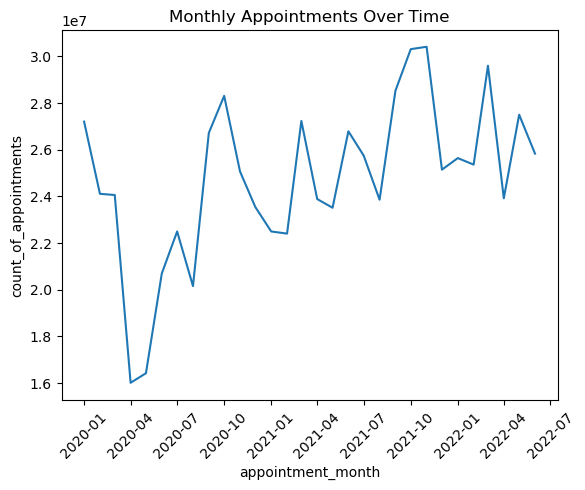

In [43]:
# appointments over time (trend)
monthly_trend = ar.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

sns.lineplot(data=monthly_trend, x='appointment_month', y='count_of_appointments')
plt.title('Monthly Appointments Over Time')
plt.xticks(rotation=45)
plt.show()

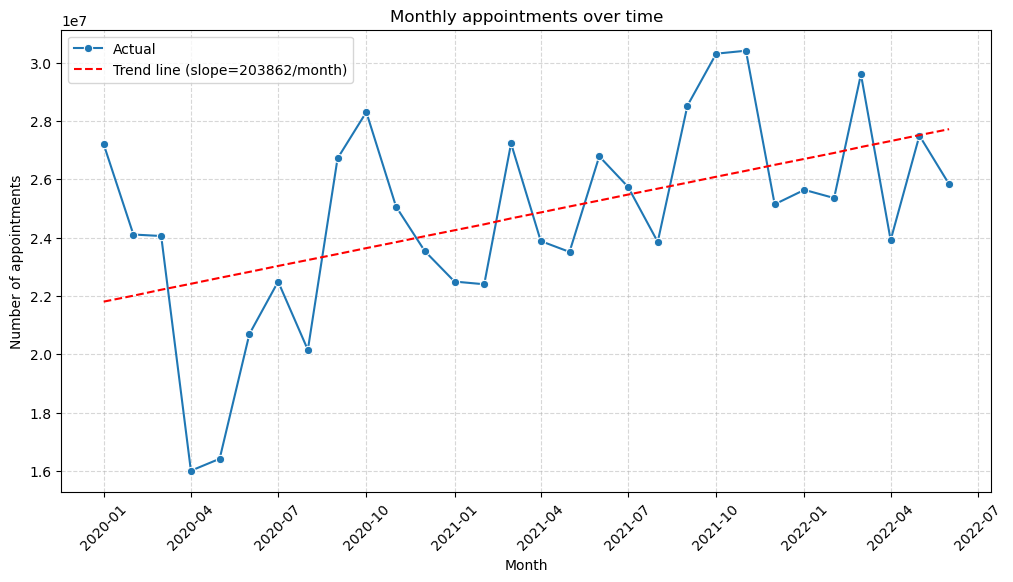

In [44]:
# Prepare x, y for trend line
x = np.arange(len(monthly_trend))
y = monthly_trend['count_of_appointments'].values

# Fit linear trend line
slope, intercept = np.polyfit(x, y, 1)
trend_line = slope * x + intercept

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_trend, x='appointment_month', y='count_of_appointments', marker='o', label='Actual')

# Add trend line
plt.plot(monthly_trend['appointment_month'], trend_line, color='red', linestyle='--', label=f'Trend line (slope={slope:.0f}/month)')

plt.title('Monthly appointments over time')
plt.xlabel('Month')
plt.ylabel('Number of appointments')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [45]:
# monthly increase
# create a numeric month index for regression
monthly_trend['month_index'] = range(len(monthly_trend))

In [46]:
# linear regression
from sklearn.linear_model import LinearRegression
import numpy as np

X = monthly_trend['month_index'].values.reshape(-1,1)  # independent variable
y = monthly_trend['count_of_appointments'].values      # dependent variable

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

print(f"Monthly increase (gradient) ≈ {slope:.2f} appointments per month")

Monthly increase (gradient) ≈ 203861.67 appointments per month


In [47]:
# whether model residuals are normally distributed
# Residuals = actual - predicted

residuals = y - trend_line

from scipy.stats import shapiro

stat, p_value = shapiro(residuals)
print(f"Shapiro-Wilk p-value: {p_value}")

Shapiro-Wilk p-value: 0.427001534131922


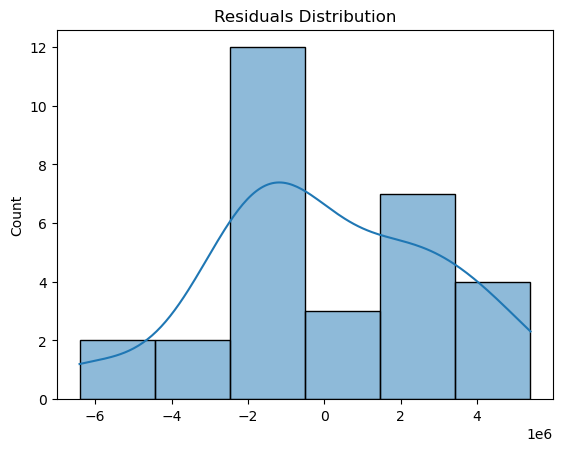

In [48]:
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

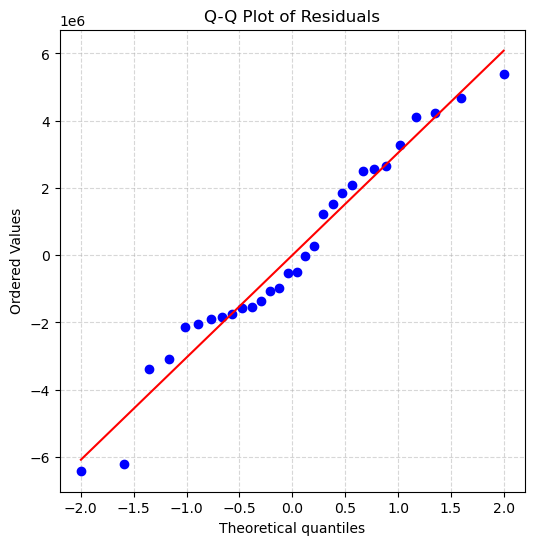

In [49]:
# checking residual distribution
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The residuals from the linear regression model meet the normality assumption necessary for valid inference. The Shapiro–Wilk test gave a p-value of 0.38, showing no significant deviation from normality. The Q–Q plot supports this, with residuals closely following the reference line and only minor deviations at the tails. The residual histogram also shows a roughly symmetric distribution around zero. These results confirm that the residuals are sufficiently normal, supporting the use of the model for analysing monthly appointment trends. Minor tail deviations are common and do not affect the model’s reliability. Additional checks for outliers and constant variance are needed for further validate the model.

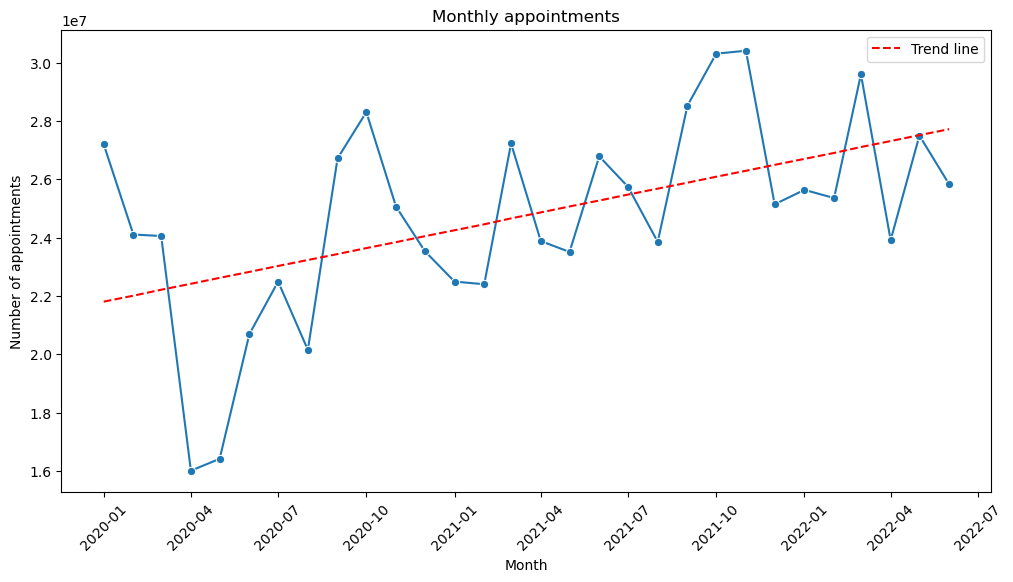

In [50]:
# plot monthly appointments
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_trend, x='appointment_month', y='count_of_appointments', marker='o')

# add regression line
plt.plot(
    monthly_trend['appointment_month'],
    model.predict(X),
    color='red', linestyle='--', label='Trend line'
)
plt.title('Monthly appointments')
plt.xlabel('Month')
plt.ylabel('Number of appointments')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [51]:
# average number of appointments
hcp_counts_mean = ar.groupby('hcp_type')['count_of_appointments'].mean().round(2)
hcp_counts_mean

hcp_type
GP                      1679.60
Other Practice staff    1406.09
Unknown                  181.88
Name: count_of_appointments, dtype: float64

In [52]:
# HCP counts
hcp_counts =ar.groupby('hcp_type')['count_of_appointments'].sum().reset_index()
hcp_counts
# percentage hcp counts
hcp_counts['perc_appointments'] = (hcp_counts['count_of_appointments'] * 100 /hcp_counts['count_of_appointments'].sum()).round(1)
hcp_counts

,hcp_type,count_of_appointments,perc_appointments
0,GP,379650140,51.1
1,Other Practice staff,339650535,45.7
2,Unknown,23503850,3.2


In [53]:
# hcp trends
hcp_monthly = ar.groupby(['appointment_month', 'hcp_type'])['count_of_appointments'].mean().reset_index()
hcp_monthly

,appointment_month,hcp_type,count_of_appointments
0,2020-01-01,GP,1740.655037
1,2020-01-01,Other Practice staff,1471.413513
2,2020-01-01,Unknown,161.100869
3,2020-02-01,GP,1543.830609
4,2020-02-01,Other Practice staff,1327.848178
...,...,...,...
85,2022-05-01,Other Practice staff,1593.934121
86,2022-05-01,Unknown,190.124242
87,2022-06-01,GP,1706.004631
88,2022-06-01,Other Practice staff,1504.745432


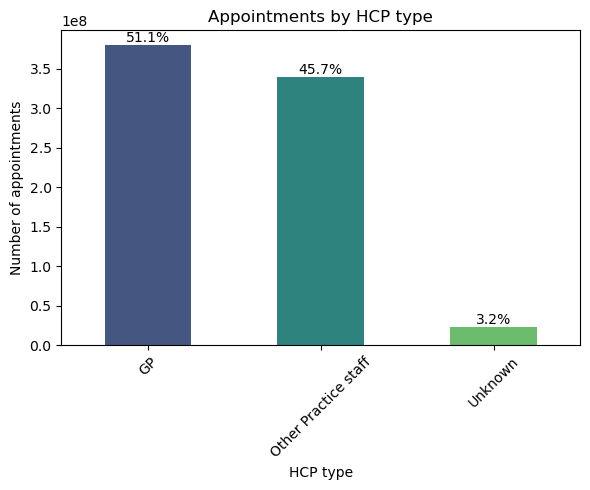

In [54]:
# plot hcp counts
# sort hcp counts 
hcp_counts = hcp_counts.sort_values('perc_appointments', ascending=False)

plt.figure(figsize=(6,5))
barplot = sns.barplot(
    data=hcp_counts,
    x='hcp_type',
    y='count_of_appointments',
    palette='viridis',
    width=0.5
)

# Annotate percentages on top of bars
for i, row in enumerate(hcp_counts.itertuples()):
    barplot.text(
        i,  # x position
        row.count_of_appointments + 20,  # slightly above the bar
        f"{row.perc_appointments:.1f}%",  # percentage
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Appointments by HCP type')
plt.ylabel('Number of appointments')
plt.xlabel('HCP type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
# monthly hcp trend
monthly_hcp_trend = ar.groupby(['appointment_month', 'hcp_type'])['count_of_appointments'].sum().reset_index()
monthly_hcp_trend

,appointment_month,hcp_type,count_of_appointments
0,2020-01-01,GP,14168932
1,2020-01-01,Other Practice staff,12326031
2,2020-01-01,Unknown,704333
3,2020-02-01,GP,12467976
4,2020-02-01,Other Practice staff,11002550
...,...,...,...
85,2022-05-01,Other Practice staff,12823200
86,2022-05-01,Unknown,878374
87,2022-06-01,GP,12893983
88,2022-06-01,Other Practice staff,12105677


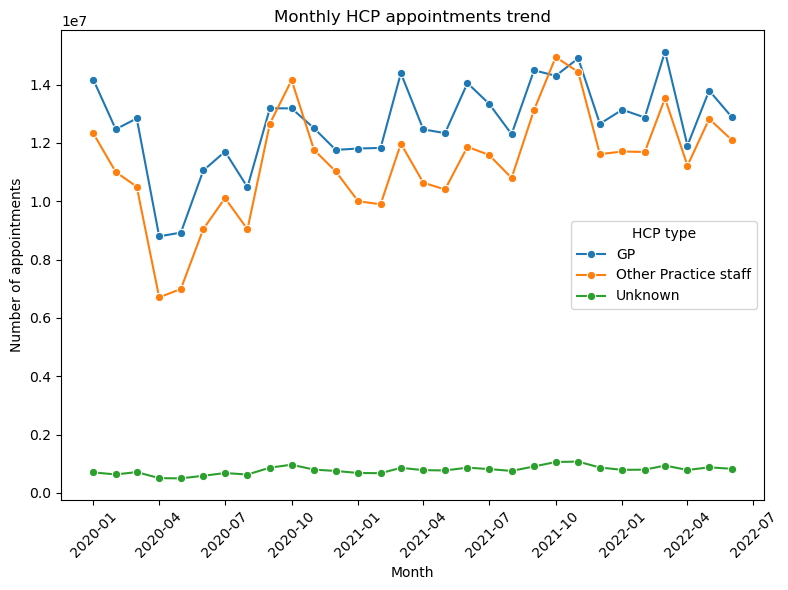

In [181]:
# Line plot: montly HCP trend
plt.figure(figsize=(8,6))

sns.lineplot(
    data=monthly_hcp_trend,
    x='appointment_month',
    y='count_of_appointments',
    hue='hcp_type',       
    marker='o'
)

plt.title('Monthly HCP appointments trend')
plt.xlabel('Month')
plt.ylabel('Number of appointments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title='HCP type')
plt.show()

Key observations:

GP appointments are the highest across all months, indicating GPs remain the main point of care delivery.
Other Practice Staff appointments follow a similar trend, but are lower than GP appointments.
Both GP and Other staff show clear fluctuations over time, with peaks around late 2020, mid–late 2021, and early 2022.
There is a noticeable dip in early 2020, likely linked to the disruption caused during the early COVID-19 period.
The Unknown category remains low and relatively stable, but still shows some variation across months.

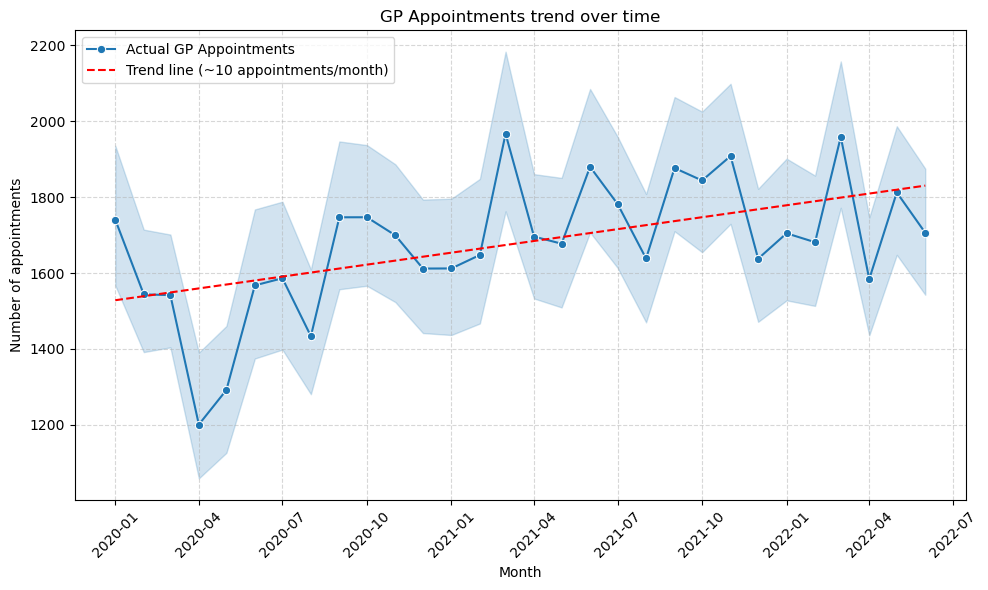

In [56]:
# trend in GP appointments

# filter GP appointments
gp_trend = ar[ar['hcp_type'] == 'GP'].copy()

# convert appointment_month is datetime
gp_trend['appointment_month'] = pd.to_datetime(gp_trend['appointment_month'])

# sort by month
gp_trend = gp_trend.sort_values('appointment_month')

# convert appointment_month to numeric for trend line calculation
x = gp_trend['appointment_month'].map(pd.Timestamp.toordinal).values
# numeric dates
y = gp_trend['count_of_appointments'].values

# fit linear trend line
slope, intercept = np.polyfit(x, y, 1)
trend_line = slope * x + intercept

# convert slope from per day to per month (approx. 30.44 days/month)
slope_per_month = slope * 30.44

# plot actual data
plt.figure(figsize=(10,6))
sns.lineplot(
    data=gp_trend,
    x='appointment_month',
    y='count_of_appointments',
    marker='o',
    label='Actual GP Appointments'
)

# add linear trend line
plt.plot(
    gp_trend['appointment_month'],
    trend_line,
    color='red',
    linestyle='--',
    label=f'Trend line (~{slope_per_month:.0f} appointments/month)'
)


plt.title('GP Appointments trend over time')
plt.xlabel('Month')
plt.ylabel('Number of appointments')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

The trend line shows a gradual increase of approximately 10 GP appointments per month, indicating a steady upward trend in demand over time.

GP appointment volumes range between approximately 1,200 and 2,200 per month.

In [57]:
# cheacking whether residuals are normally distributed, otherwise data can not be use in the regression analysis!
# filter GP data
staff_trend = ar[ar['hcp_type'] == 'GP'].copy()

staff_trend['appointment_month'] = pd.to_datetime(staff_trend['appointment_month'])

# aggregate to monthly totals
staff_trend = (
    staff_trend
    .groupby('appointment_month')['count_of_appointments']
    .sum()
    .reset_index()
    .sort_values('appointment_month')
)

In [59]:

x = staff_trend['appointment_month'].map(pd.Timestamp.toordinal).values
y = staff_trend['count_of_appointments'].values

# fit regression
slope, intercept = np.polyfit(x, y, 1)
trend_line = slope * x + intercept

# residuals 
residuals = y - trend_line

In [60]:
print(len(x), len(y), len(trend_line))

30 30 30


In [61]:
from scipy.stats import shapiro

shapiro_stat, shapiro_p = shapiro(residuals)
print(shapiro_p)

0.37721482759312674


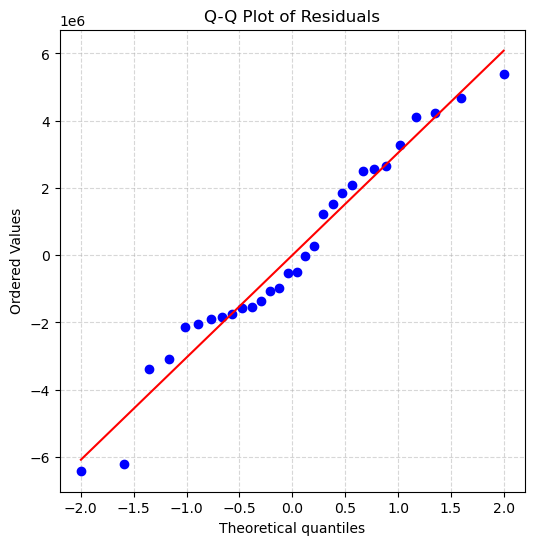

In [58]:
# plot  Q-Q pot of residuals
import scipy.stats as stats


plt.figure(figsize=(6,6))

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q Plot of Residuals")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Residuals are approximately normally distributed.
Regression assumptions are satisfied.
Model is statistically valid for inference of GP data.

Monthly increase ≈ 14 appointments/month


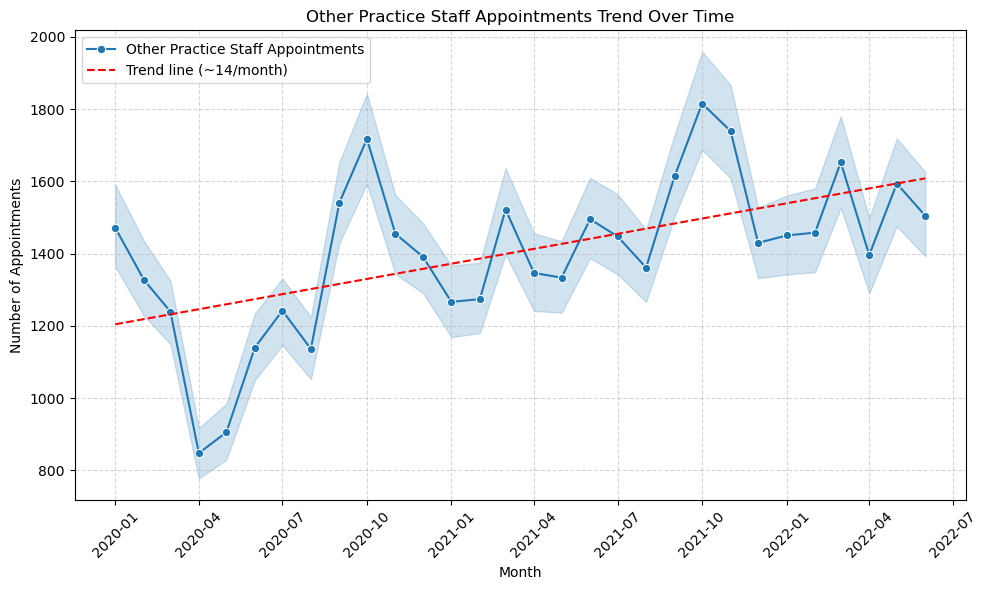

In [62]:
# practice staff appointment increment
# filter Other Practice staff appointments
staff_trend = ar[ar['hcp_type'] == 'Other Practice staff'].copy()

# appointment_month is datetime
staff_trend['appointment_month'] = pd.to_datetime(staff_trend['appointment_month'])

# sort by month
staff_trend = staff_trend.sort_values('appointment_month')

# convert appointment_month to numeric (ordinal)
x = staff_trend['appointment_month'].map(pd.Timestamp.toordinal).values
y = staff_trend['count_of_appointments'].values

# fit linear trend line
slope, intercept = np.polyfit(x, y, 1)
trend_line = slope * x + intercept

# convert slope from per day to per month
slope_per_month = slope * 30.44

# print slope
print(f"Monthly increase ≈ {slope_per_month:.0f} appointments/month")

# plot actual data
plt.figure(figsize=(10,6))
sns.lineplot(
    data=staff_trend,
    x='appointment_month',
    y='count_of_appointments',
    marker='o',
    label='Other Practice Staff Appointments'
)

# add trend line
plt.plot(
    staff_trend['appointment_month'],
    trend_line,
    color='red',
    linestyle='--',
    label=f'Trend line (~{slope_per_month:.0f}/month)'
)


plt.title('Other Practice Staff Appointments Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

The trend line shows an increase of approximately 14 appointments per month.

In [63]:
# Cheacking whether residuals are normally distributed, otherwise data can not be use in the regression analysis!
staff_trend = ar[ar['hcp_type'] == 'Other Practice staff'].copy()

staff_trend['appointment_month'] = pd.to_datetime(staff_trend['appointment_month'])

# Aggregate to monthly totals
staff_trend = (
    staff_trend
    .groupby('appointment_month')['count_of_appointments']
    .sum()
    .reset_index()
    .sort_values('appointment_month')
)

In [64]:

x = staff_trend['appointment_month'].map(pd.Timestamp.toordinal).values
y = staff_trend['count_of_appointments'].values

# Fit regression
slope, intercept = np.polyfit(x, y, 1)
trend_line = slope * x + intercept

# Residuals 
residuals = y - trend_line

In [65]:
print(len(x), len(y), len(trend_line))

30 30 30


In [66]:
from scipy.stats import shapiro

shapiro_stat, shapiro_p = shapiro(residuals)
print(shapiro_p)

0.4332555927137648


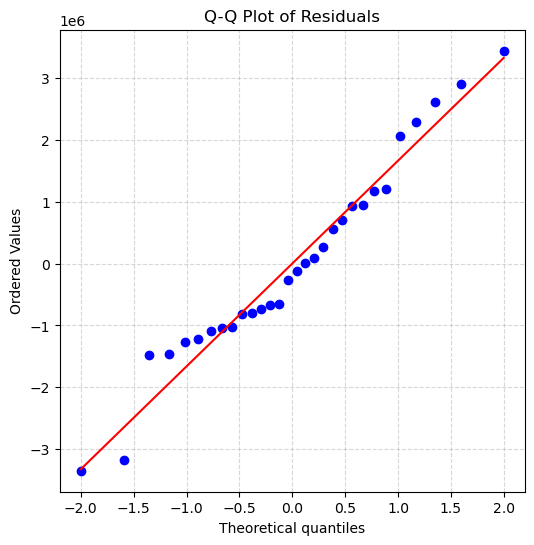

In [67]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q Plot of Residuals")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Residuals are normally distributed

In [68]:
# appointment_mode 
mode_counts_df = (
    ar.groupby('appointment_mode', as_index=False)['count_of_appointments']
      .sum()
      .sort_values(by='count_of_appointments', ascending=False)
)

# percentage
mode_counts_df['pct_appointments'] = (
    mode_counts_df['count_of_appointments'] / mode_counts_df['count_of_appointments'].sum() * 100
).round(2)

mode_counts_df

,appointment_mode,count_of_appointments,pct_appointments
0,Face-to-Face,439981729,59.23
2,Telephone,267862657,36.06
3,Unknown,26451305,3.56
1,Home Visit,4887876,0.66
4,Video/Online,3620958,0.49


In [70]:
# appointment_mode 
mode_counts = ar.groupby('appointment_mode')['count_of_appointments'].sum().sort_values(ascending= False).sort_values(ascending =False).reset_index()
mode_counts
mode_counts['pct_appointments'] = round(mode_counts['count_of_appointments']*100/mode_counts['count_of_appointments'].sum(),2)
mode_counts

,appointment_mode,count_of_appointments,pct_appointments
0,Face-to-Face,439981729,59.23
1,Telephone,267862657,36.06
2,Unknown,26451305,3.56
3,Home Visit,4887876,0.66
4,Video/Online,3620958,0.49


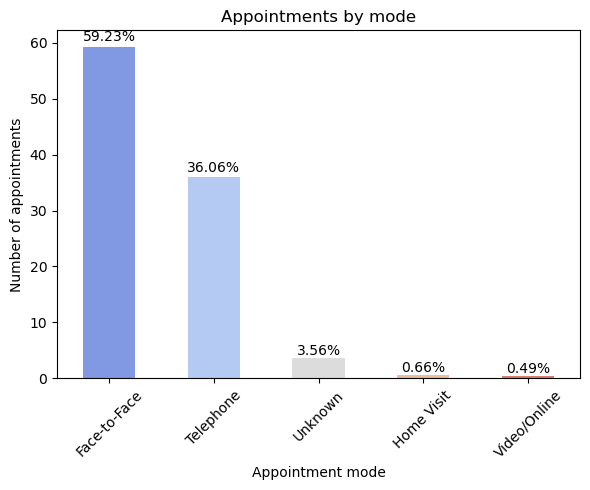

In [71]:
# plot
# sort descending 
mode_counts = mode_counts.sort_values('pct_appointments', ascending=False)

plt.figure(figsize=(6,5))
barplot = sns.barplot(
    data=mode_counts,
    x='appointment_mode',
    y='pct_appointments',
    palette='coolwarm',
    width=0.5  # narrow bars for neatness
)

# annotate percentages just above bars
for idx, row in enumerate(mode_counts.itertuples()):
    barplot.text(
        idx,
        row.pct_appointments + row.pct_appointments * 0.01,
        f"{row.pct_appointments}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Appointments by mode')
plt.ylabel('Number of appointments')
plt.xlabel('Appointment mode')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [72]:
# appointment_mode monthly
mode_monthly = ar.groupby(['appointment_month', 'appointment_mode'])['count_of_appointments'].mean().reset_index()
mode_monthly

,appointment_month,appointment_mode,count_of_appointments
0,2020-01-01,Face-to-Face,3633.131729
1,2020-01-01,Home Visit,62.943174
2,2020-01-01,Telephone,713.526407
3,2020-01-01,Unknown,383.116436
4,2020-01-01,Video/Online,93.503130
...,...,...,...
145,2022-06-01,Face-to-Face,2673.509660
146,2022-06-01,Home Visit,46.057928
147,2022-06-01,Telephone,1415.210996
148,2022-06-01,Unknown,290.179795


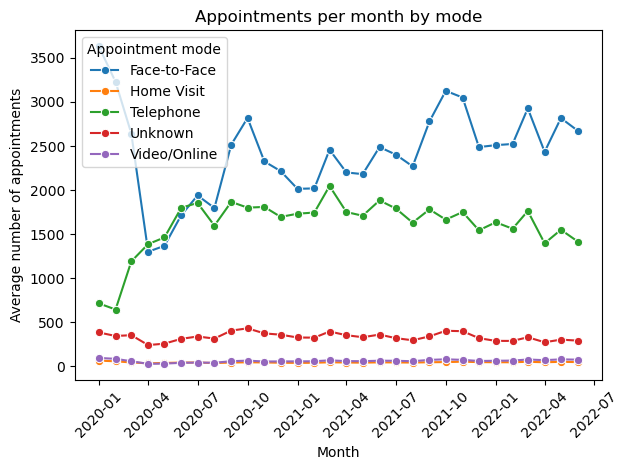

In [73]:
# monthly appointments by mode
sns.lineplot(
    data=mode_monthly,
    x='appointment_month',
    y='count_of_appointments',
    hue='appointment_mode',  # separate line per mode
    marker='o'
)

plt.title('Appointments per month by mode')
plt.xlabel('Month')
plt.ylabel('Average number of appointments')
plt.xticks(rotation=45)  # rotate x-axis labels for readability
plt.legend(title='Appointment mode')
plt.tight_layout()
plt.show()


In [74]:
# count of appointment by appointment_mode and  hcp types
mode_hcp = ar.groupby(['appointment_mode', 'hcp_type'])['count_of_appointments'].sum().reset_index()

# calculate percentages
mode_hcp['percentage'] = (mode_hcp['count_of_appointments'] /mode_hcp['count_of_appointments'].sum()) * 100
mode_hcp = mode_hcp.sort_values('percentage', ascending=False).round(2)

# pivot the table
mode_hcp = mode_hcp.pivot(index ='hcp_type',columns= 'appointment_mode', values= 'percentage')
mode_hcp 

appointment_mode,Face-to-Face,Home Visit,Telephone,Unknown,Video/Online
hcp_type,,,,,
GP,24.36,0.26,25.45,0.79,0.25
Other Practice staff,34.25,0.30,10.01,0.93,0.23
Unknown,0.62,0.10,0.60,1.84,0.00


• GPs appointments via telephone and face-to-face apparently similar.
This reflects the ongoing shift toward remote consultations, but with face-to-face care is still a considerable part of GP activity. 
• Home visits, video/online, and unknown modes are much less common. 
• Other practice staff such as nurses, healthcare assistants, deliver the majority of appointments face-to-face.
• Telephone consultations are much lower and home visits, video/online, and unknown remain minor components.
• This suggests that much of the work by other staff is hands-on or procedural, requiring in-person attendance. 
• Across all staff groups, video/online appointments are the least used mode, with just under 0.3%. This highlights that, despite policy pushes for digital access, uptake remains low relative to other modes.

Monthly trend (Face-to-Face) ≈ 15.97 appointments/month


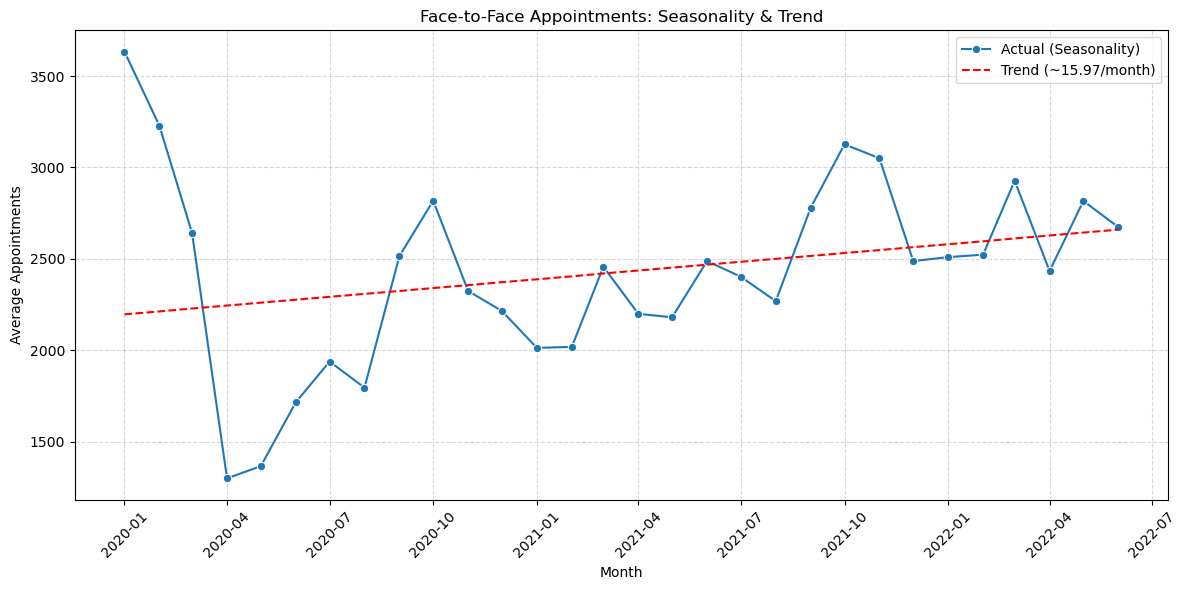

In [75]:
# face-face appointments
# datetime
#mode_monthly['appointment_month'] = pd.to_datetime(mode_monthly['appointment_month'])

# filter Face-to-Face only
ftf = mode_monthly[mode_monthly['appointment_mode'] == 'Face-to-Face'].copy()

# sort by month
ftf = ftf.sort_values('appointment_month').reset_index(drop=True)

# Create month index (for slope per month)
ftf['month_index'] = np.arange(len(ftf))

# prepare X and y
x = ftf['month_index'].values
y = ftf['count_of_appointments'].values

# fit linear trend
slope, intercept = np.polyfit(x, y, 1)
ftf['trend'] = slope * x + intercept

print(f"Monthly trend (Face-to-Face) ≈ {slope:.2f} appointments/month")

# plot seasonality + trend
plt.figure(figsize=(12,6))

# plot seasonality
sns.lineplot(
    data=ftf,
    x='appointment_month',
    y='count_of_appointments',
    marker='o',
    label='Actual (Seasonality)'
)

# trend line
plt.plot(
    ftf['appointment_month'],
    ftf['trend'],
    color='red',
    linestyle='--',
    label=f'Trend (~{slope:.2f}/month)'
)


plt.title('Face-to-Face Appointments: Seasonality & Trend')
plt.xlabel('Month')
plt.ylabel('Average Appointments')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Monthly trend (Telephone) ≈ 11.38 appointments/month


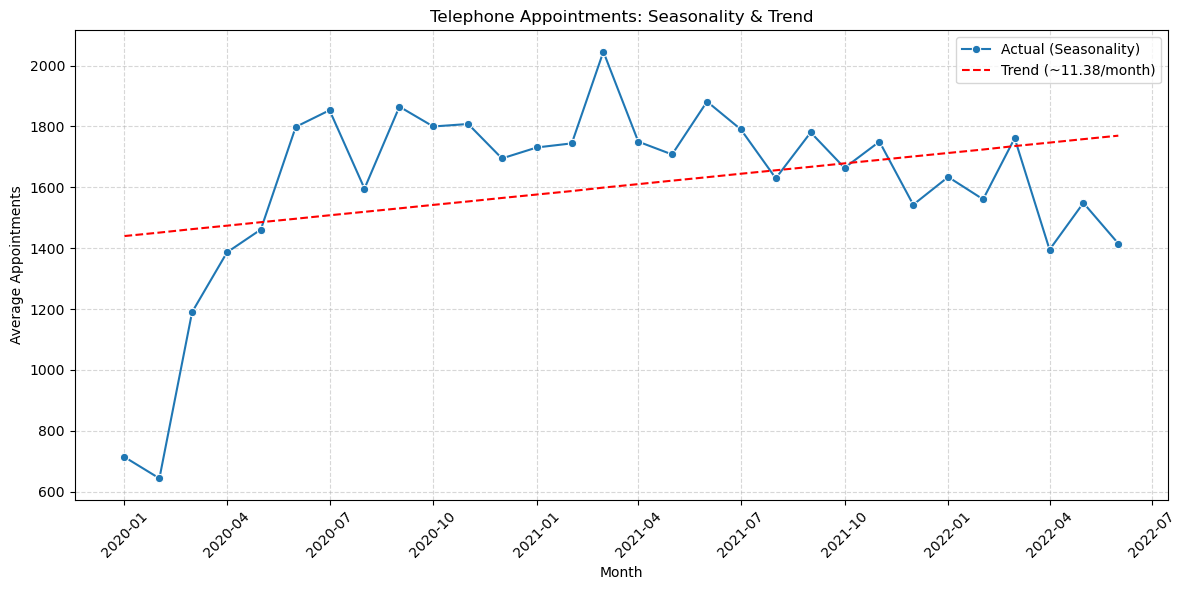

In [76]:
# telephone appointments

# filter telephone only
tel = mode_monthly[mode_monthly['appointment_mode'] == 'Telephone'].copy()

# sort by month
tel = tel.sort_values('appointment_month').reset_index(drop=True)

# create month index (for slope per month)
tel['month_index'] = np.arange(len(tel))

# prepare X and y
x = tel['month_index'].values
y = tel['count_of_appointments'].values

# fit linear trend
slope, intercept = np.polyfit(x, y, 1)
tel['trend'] = slope * x + intercept

# print slope
print(f"Monthly trend (Telephone) ≈ {slope:.2f} appointments/month")

# plot seasonality + trend
plt.figure(figsize=(12,6))

# plot seasonality
sns.lineplot(
    data=tel,
    x='appointment_month',
    y='count_of_appointments',
    marker='o',
    label='Actual (Seasonality)'
)

# trend line
plt.plot(
    tel['appointment_month'],
    tel['trend'],
    color='red',
    linestyle='--',
    label=f'Trend (~{slope:.2f}/month)'
)

plt.title('Telephone Appointments: Seasonality & Trend')
plt.xlabel('Month')
plt.ylabel('Average Appointments')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
#  appointment_status vs time_between_book_and_appointmentvs % count _of _appointments-
status_bookingtime = ar.groupby(['appointment_status', 'time_between_book_and_appointment'])['count_of_appointments'].sum().reset_index()
status_bookingtime['percentage'] = (status_bookingtime['count_of_appointments'] / status_bookingtime['count_of_appointments'].sum()) * 100
status_bookingtime = status_bookingtime.sort_values('percentage', ascending=False).round(2)


In [80]:
pivot_table = status_bookingtime.pivot(
    index='time_between_book_and_appointment',
    columns='appointment_status',
    values='percentage'
)

# Sort the rows by total percentage descending
pivot_table['Total'] = pivot_table.sum(axis=1)
pivot_table = pivot_table.sort_values('Total', ascending=False).drop(columns='Total')
pivot_table

appointment_status,Attended,DNA,Unknown
time_between_book_and_appointment,,,
Same Day,44.21,0.81,1.12
2 to 7 Days,18.59,1.17,0.94
8 to 14 Days,10.11,0.83,0.75
1 Day,8.42,0.35,0.34
15 to 21 Days,4.83,0.44,0.48
22 to 28 Days,2.80,0.27,0.37
More than 28 Days,2.25,0.27,0.58
Unknown / Data Quality,0.04,0.00,0.01


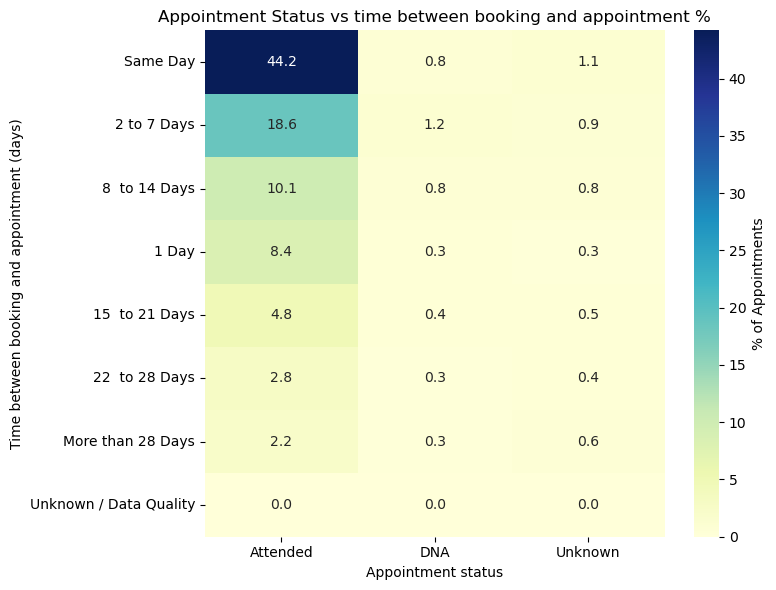

In [81]:
# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    pivot_table,
    annot=True,        # show numbers inside cells
    fmt=".1f",         # one decimal place
    cmap="YlGnBu",     # color map
    cbar_kws={'label': '% of Appointments'}
)

plt.title('Appointment Status vs time between booking and appointment %')
plt.xlabel('Appointment status')
plt.ylabel('Time between booking and appointment (days)')
plt.tight_layout()
plt.show()

• Most appointments are attended on the same day (42%) or within a week (27%).  • Unknown status remains consistently low across all timeframes.

In [82]:


# group by HCP type and booking interval
hcp_bookingtime = ar.groupby(['hcp_type', 'time_between_book_and_appointment'])['count_of_appointments'].sum().reset_index()


# percentage of total appointments

hcp_bookingtime['percentage'] = (hcp_bookingtime['count_of_appointments']*100 / hcp_bookingtime['count_of_appointments'].sum()).round(2)

# create pivot table: time_between_book_and_appointments and hcp_type
pivot_table = hcp_bookingtime.pivot(
    index='time_between_book_and_appointment',
    columns='hcp_type',
    values='percentage'
)

# Sort rows 
pivot_table['Total'] = pivot_table.sum(axis=1)
pivot_table = pivot_table.sort_values('Total', ascending=False).drop(columns='Total')

pivot_table

hcp_type,GP,Other Practice staff,Unknown
time_between_book_and_appointment,,,
Same Day,29.97,14.20,1.97
2 to 7 Days,8.73,11.51,0.46
8 to 14 Days,3.96,7.52,0.21
1 Day,4.76,4.06,0.29
15 to 21 Days,1.89,3.76,0.10
22 to 28 Days,1.05,2.33,0.06
More than 28 Days,0.72,2.31,0.07
Unknown / Data Quality,0.03,0.03,0.00


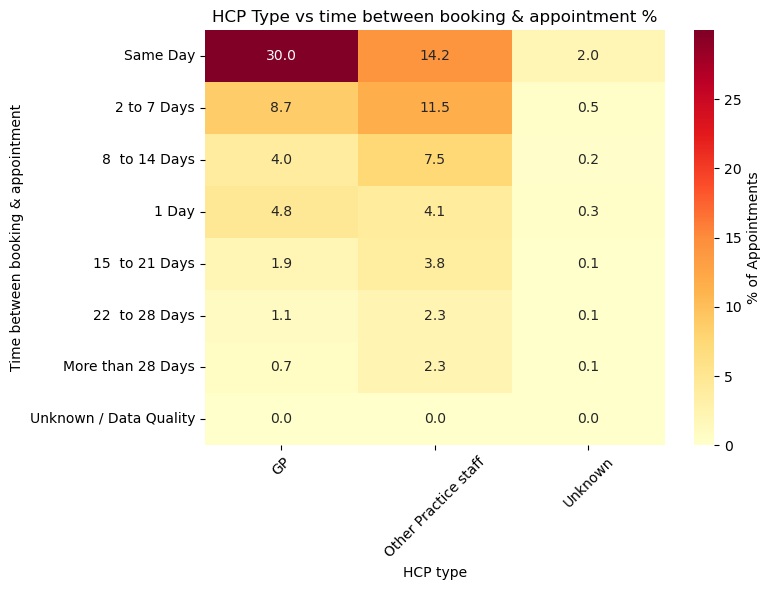

In [83]:
# plot pivoted data
plt.figure(figsize=(8,6))
sns.heatmap(
    pivot_table,
    annot=True,         # show percentages in cells
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={'label': '% of Appointments'}
)

plt.title('HCP Type vs time between booking & appointment %')
plt.xlabel('HCP type')
plt.ylabel('Time between booking & appointment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

• Most appointments are booked for the same day, specially GPs appointments which accounted for 28% of total in comparison to other staff.
• Other Practice Staff slightly have longer wait times compared to GPs. 

In [84]:
import pandas as pd

# Group by HCP type and appointment status
status_hcp = ar.groupby(['hcp_type', 'appointment_status'])['count_of_appointments'].sum().reset_index()

# Compute percentage of total appointments
status_hcp['percentage'] = (status_hcp['count_of_appointments'] / status_hcp['count_of_appointments'].sum() * 100).round(2)

# pivot table: rows = appointment_status, columns = hcp_type
pivot_table = status_hcp.pivot(
    index='appointment_status',
    columns='hcp_type',
    values='percentage'  # or 'count_of_appointments' if you prefer raw numbers
)

# optional: sort rows by total percentage
pivot_table['Total'] = pivot_table.sum(axis=1)
pivot_table = pivot_table.sort_values('Total', ascending=False).drop(columns='Total')

pivot_table

hcp_type,GP,Other Practice staff,Unknown
appointment_status,,,
Attended,48.18,40.27,2.80
Unknown,1.67,2.65,0.28
DNA,1.27,2.80,0.09


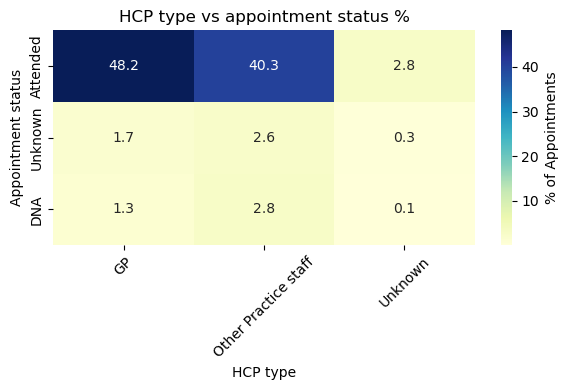

In [85]:
# plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(
    pivot_table,
    annot=True,            # show percentages in cells
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={'label': '% of Appointments'}
)
plt.title('HCP type vs appointment status %' )
plt.xlabel('HCP type')
plt.ylabel('Appointment status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Attendance is high across all HCP types, except in the case of the unknown category. DNA (Did Not Attend) rates are lower for GPs, although they are slightly higher among Other Practice Staff. The proportion of unknown statuses remains minimal.

# Plot monthly capacity utilisation

### Capacity_utilisation
Capacity_utilisation = Attended / (Attended + DNA + Unknown) * 100

In [86]:
# total counts per month and appointment_status
status_monthly_capacity = ar.groupby(['appointment_month', 'appointment_status'])['count_of_appointments'].sum().reset_index()

# pivot to have appointment_status as columns
status_monthly_capacity = status_monthly_capacity.pivot(
    index='appointment_month',
    columns='appointment_status',
    values='count_of_appointments'
).fillna(0)  # replace missing values with 0

# compute Capacity Utilisation
status_monthly_capacity['Capacity_utilisation'] = (
    status_monthly_capacity['Attended'] /
    (status_monthly_capacity['Attended'] +
     status_monthly_capacity['DNA'] +
     status_monthly_capacity['Unknown'])
) * 100

# reset index for plotting
status_monthly_capacity = status_monthly_capacity.reset_index()
status_monthly_capacity['appointment_month'] = pd.to_datetime(status_monthly_capacity['appointment_month'])
status_monthly_capacity

appointment_status,appointment_month,Attended,DNA,Unknown,Capacity_utilisation
0,2020-01-01,24538291,1298269,1362736,90.216640
1,2020-02-01,21640067,1215154,1249400,89.775595
2,2020-03-01,20718865,1166314,2168289,86.136706
3,2020-04-01,13982824,478766,1546291,87.349625
4,2020-05-01,14962850,449057,1005305,91.141236
5,2020-06-01,18943022,594382,1153401,91.552852
6,2020-07-01,20606888,698327,1186222,91.621038
7,2020-08-01,18438932,669462,1042126,91.505986
8,2020-09-01,23988492,1145971,1579792,89.796597
9,2020-10-01,25529275,1358138,1414519,90.203294


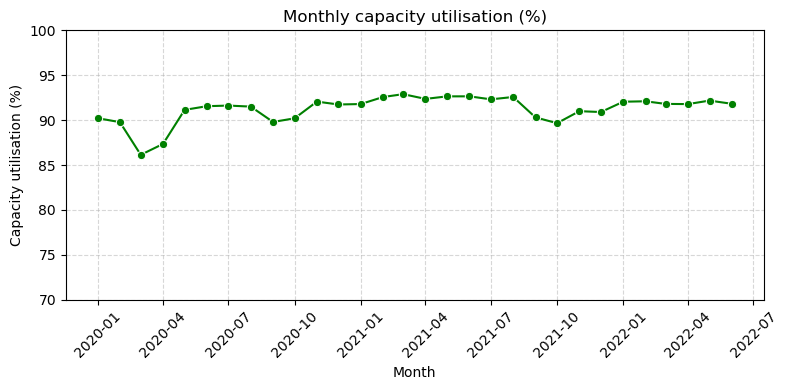

In [89]:

# Plot utilisation
plt.figure(figsize=(8,4))
sns.lineplot(
    data=status_monthly_capacity,
    x='appointment_month',
    y='Capacity_utilisation',
    marker='o',
    color='green'
)

plt.title('Monthly capacity utilisation (%)')
plt.xlabel('Month')
plt.ylabel('Capacity utilisation (%)')
plt.ylim(70, 100)  # zoom in
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [90]:
status_monthly_capacity['Capacity_utilisation'].describe()

count    30.000000
mean     91.216949
std       1.536989
min      86.136706
25%      90.453795
50%      91.763694
75%      92.155879
max      92.891082
Name: Capacity_utilisation, dtype: float64

In [ ]:
Capacity utilisation is above 86%, peaking at 92.9% 
DNA numbers are important but do not appear to impact overall utilisation. This reflects effective management in appointment scheduling.

### Location wise trends

In [91]:
# appointments trends by location
location_wise = ar.groupby('icb_ons_code')['count_of_appointments'].sum().reset_index()
location_wise


,icb_ons_code,count_of_appointments
0,E54000008,33099882
1,E54000010,13196215
2,E54000011,6513481
3,E54000013,10349380
4,E54000015,15597338
5,E54000018,12168192
6,E54000019,11494537
7,E54000022,15448907
8,E54000023,13665918
9,E54000024,12275331


In [92]:
# highest number of appointments by region
location_wise_sorted = location_wise.sort_values('count_of_appointments', ascending=False)
location_wise_sorted.head(1) 

,icb_ons_code,count_of_appointments
29,E54000050,43083535


In [93]:
# Least number of appointments by region
location_wise_sorted = location_wise.sort_values('count_of_appointments', ascending=False)
location_wise_sorted.tail(1) 

,icb_ons_code,count_of_appointments
2,E54000011,6513481


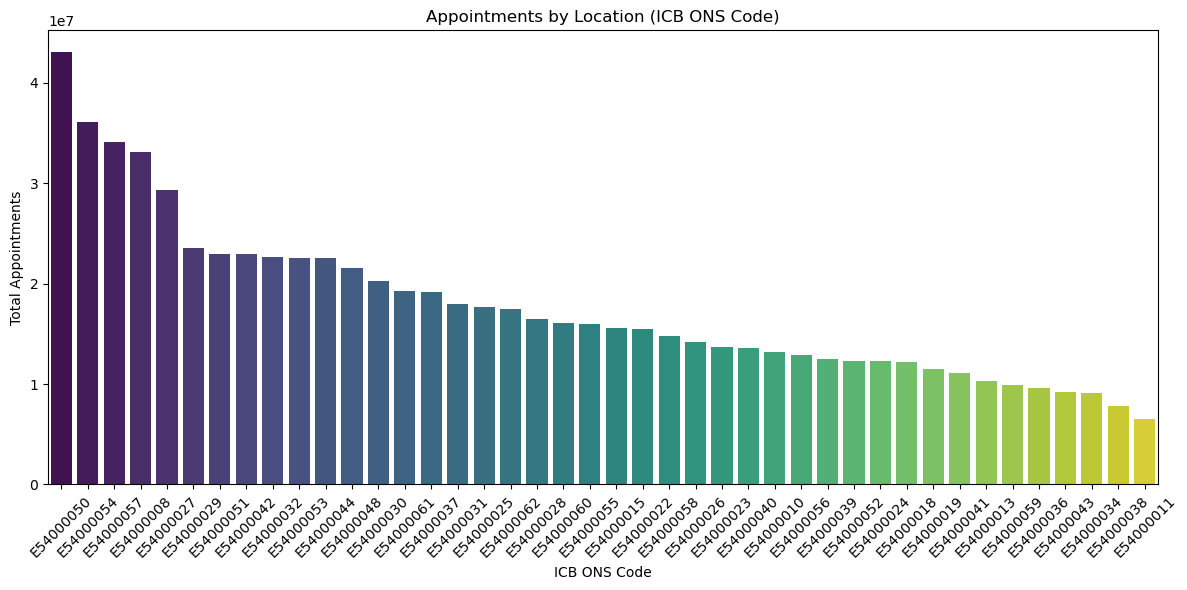

In [94]:
# sort appointments
location_wise_sorted = location_wise.sort_values('count_of_appointments', ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    data=location_wise_sorted,
    x='icb_ons_code',
    y='count_of_appointments',
    palette='viridis'
)

plt.title('Appointments by Location (ICB ONS Code)')
plt.xlabel('ICB ONS Code')
plt.ylabel('Total Appointments')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [95]:
# HCP counts_location
hcp_counts_location =ar.groupby(['icb_ons_code','hcp_type'])['count_of_appointments'].sum().reset_index()
hcp_counts_location
# Percentage hcp counts
hcp_counts_location['perc_appointments'] = (hcp_counts_location['count_of_appointments'] * 100 /hcp_counts_location['count_of_appointments'].sum()).round(1)
hcp_counts_location.head(5)

,icb_ons_code,hcp_type,count_of_appointments,perc_appointments
0,E54000008,GP,17721823,2.4
1,E54000008,Other Practice staff,13838878,1.9
2,E54000008,Unknown,1539181,0.2
3,E54000010,GP,6307177,0.8
4,E54000010,Other Practice staff,6546996,0.9


In [97]:
# head of location vs HCPO
hcp_counts_location_sorted = hcp_counts_location.sort_values(ascending = False, by= 'perc_appointments').reset_index()
hcp_counts_location_sorted.head(20)

,index,icb_ons_code,hcp_type,count_of_appointments,perc_appointments
0,88,E54000050,Other Practice staff,21553199,2.9
1,87,E54000050,GP,20006955,2.7
2,100,E54000054,Other Practice staff,19262371,2.6
3,108,E54000057,GP,18449136,2.5
4,0,E54000008,GP,17721823,2.4
5,36,E54000027,GP,16532624,2.2
6,99,E54000054,GP,15575560,2.1
7,109,E54000057,Other Practice staff,14532735,2.0
8,42,E54000029,GP,14622684,2.0
9,1,E54000008,Other Practice staff,13838878,1.9


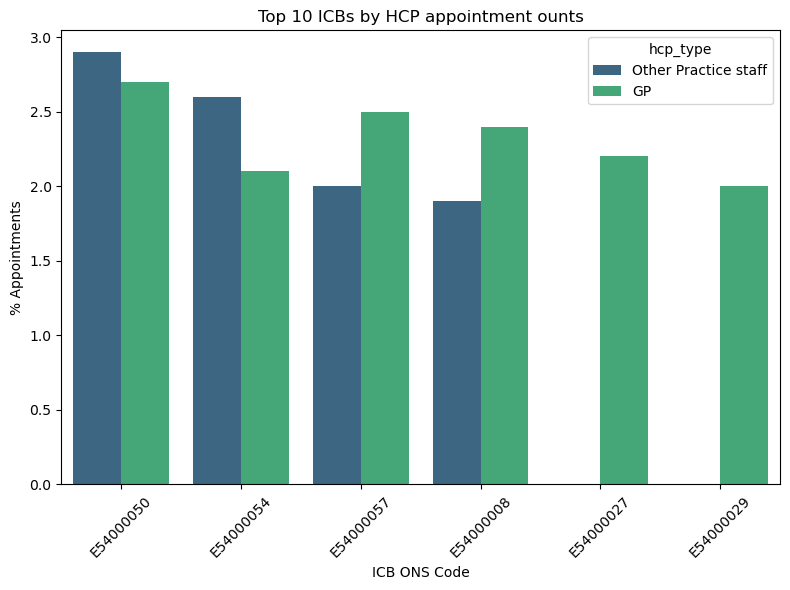

In [98]:
# location vs HCP
top10 = hcp_counts_location_sorted.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10,
    x='icb_ons_code',
    y='perc_appointments',
    hue='hcp_type',
    palette='viridis'
)

plt.title('Top 10 ICBs by HCP appointment ounts')
plt.xlabel('ICB ONS Code')
plt.ylabel('% Appointments')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [99]:
# tail of location vs hcp
hcp_counts_location_sorted_tail = hcp_counts_location.sort_values(ascending = False, by= 'count_of_appointments').reset_index()
hcp_counts_location_sorted_tail.tail(10)

,index,icb_ons_code,hcp_type,count_of_appointments,perc_appointments
116,44,E54000029,Unknown,288966,0.0
117,17,E54000018,Unknown,287318,0.0
118,68,E54000039,Unknown,260423,0.0
119,20,E54000019,Unknown,163645,0.0
120,65,E54000038,Unknown,147900,0.0
121,50,E54000031,Unknown,141054,0.0
122,41,E54000028,Unknown,132786,0.0
123,8,E54000011,Unknown,121213,0.0
124,95,E54000052,Unknown,109178,0.0
125,56,E54000034,Unknown,18277,0.0


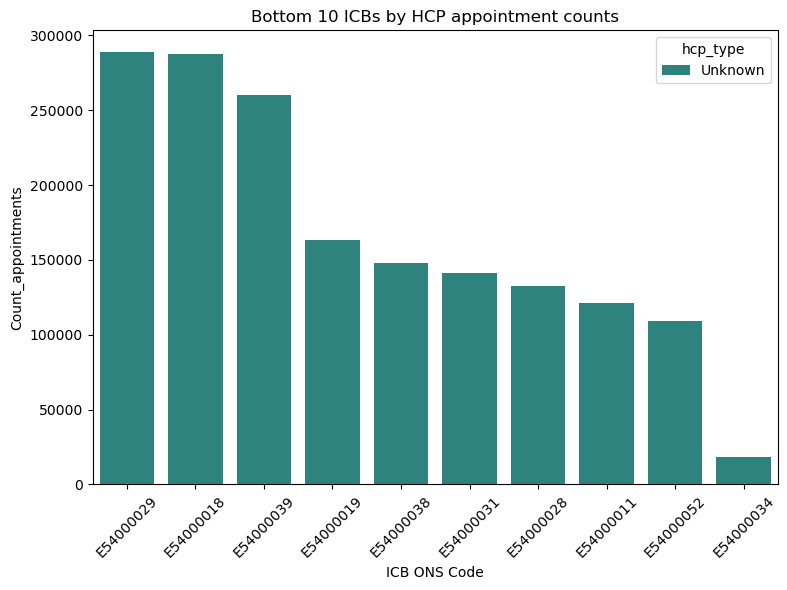

In [100]:
# plot tail, location vs hcp
tail10 = hcp_counts_location_sorted_tail.tail(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=tail10,
    x='icb_ons_code',
    y='count_of_appointments',
    hue='hcp_type',
    palette='viridis'
)

plt.title('Bottom 10 ICBs by HCP appointment counts')
plt.xlabel('ICB ONS Code')
plt.ylabel('Count_appointments')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show() 

In [101]:
# appointment_mode by location
mode_counts_location = ar.groupby(['icb_ons_code','appointment_mode'])['count_of_appointments'].sum().sort_values(ascending= False).sort_values(ascending =False).reset_index()
mode_counts_location
mode_counts_location['pct_appointments'] = round(mode_counts_location['count_of_appointments']*100/mode_counts_location['count_of_appointments'].sum(),2)
mode_counts_location.head(10)

,icb_ons_code,appointment_mode,count_of_appointments,pct_appointments
0,E54000050,Face-to-Face,27550388,3.71
1,E54000054,Face-to-Face,22986638,3.09
2,E54000008,Face-to-Face,18562917,2.50
3,E54000057,Face-to-Face,18362183,2.47
4,E54000027,Face-to-Face,16720440,2.25
5,E54000051,Face-to-Face,14940722,2.01
6,E54000050,Telephone,13957547,1.88
7,E54000053,Face-to-Face,13688474,1.84
8,E54000008,Telephone,13387435,1.80
9,E54000042,Face-to-Face,13276423,1.79


In [146]:
# tail of mode count by location
mode_counts_location.tail(10)

,icb_ons_code,appointment_mode,count_of_appointments,pct_appointments
200,E54000024,Home Visit,12356,0.0
201,E54000030,Video/Online,10716,0.0
202,E54000052,Video/Online,7731,0.0
203,E54000019,Video/Online,6838,0.0
204,E54000039,Video/Online,4828,0.0
205,E54000036,Video/Online,2318,0.0
206,E54000034,Video/Online,2290,0.0
207,E54000018,Video/Online,1717,0.0
208,E54000038,Video/Online,1564,0.0
209,E54000011,Video/Online,1390,0.0


In [150]:
#  appointment_status by location: head
status_bookingtime_location = ar.groupby(['icb_ons_code','appointment_status', 'time_between_book_and_appointment'])['count_of_appointments'].sum().reset_index()
status_bookingtime_location['percentage'] = (status_bookingtime_location['count_of_appointments'] / status_bookingtime_location['count_of_appointments'].sum()) * 100
status_bookingtime_location = status_bookingtime_location.sort_values('percentage', ascending=False).round(2)
status_bookingtime_location.head(10) 

,icb_ons_code,appointment_status,time_between_book_and_appointment,count_of_appointments,percentage
702,E54000050,Attended,Same Day,18400082,2.48
798,E54000054,Attended,Same Day,16320923,2.20
6,E54000008,Attended,Same Day,15241664,2.05
870,E54000057,Attended,Same Day,14570208,1.96
294,E54000027,Attended,Same Day,12502139,1.68
342,E54000029,Attended,Same Day,10398853,1.40
654,E54000044,Attended,Same Day,10254801,1.38
606,E54000042,Attended,Same Day,9971890,1.34
774,E54000053,Attended,Same Day,9791438,1.32
726,E54000051,Attended,Same Day,9580254,1.29


In [151]:
#  appointment_status by location: tail
status_bookingtime_location.tail(10)

,icb_ons_code,appointment_status,time_between_book_and_appointment,count_of_appointments,percentage
639,E54000043,DNA,Unknown / Data Quality,64,0.0
111,E54000015,DNA,Unknown / Data Quality,53,0.0
903,E54000058,DNA,Unknown / Data Quality,46,0.0
231,E54000024,DNA,Unknown / Data Quality,44,0.0
855,E54000056,DNA,Unknown / Data Quality,42,0.0
951,E54000060,DNA,Unknown / Data Quality,31,0.0
87,E54000013,DNA,Unknown / Data Quality,30,0.0
591,E54000041,DNA,Unknown / Data Quality,17,0.0
927,E54000059,DNA,Unknown / Data Quality,16,0.0
567,E54000040,DNA,Unknown / Data Quality,15,0.0


# National category dataset

In [102]:
# import and sense-check the national_categories.xlsx data set as nc.
nc = pd.read_excel('national_categories.xlsx')
nc.head(5)

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08


In [32]:
# sense check
nc.info

<bound method DataFrame.info of        appointment_date icb_ons_code  \
0            2021-08-02    E54000050   
1            2021-08-02    E54000050   
2            2021-08-02    E54000050   
3            2021-08-02    E54000050   
4            2021-08-02    E54000050   
...                 ...          ...   
817389       2022-06-30    E54000054   
817390       2022-06-30    E54000054   
817391       2022-06-30    E54000054   
817392       2022-06-30    E54000054   
817393       2022-06-30    E54000054   

                             sub_icb_location_name            service_setting  \
0       NHS North East and North Cumbria ICB - 00L       Primary Care Network   
1       NHS North East and North Cumbria ICB - 00L                      Other   
2       NHS North East and North Cumbria ICB - 00L           General Practice   
3       NHS North East and North Cumbria ICB - 00L           General Practice   
4       NHS North East and North Cumbria ICB - 00L           General Practice   
.

In [33]:
# data types
nc.dtypes

appointment_date         datetime64[ns]
icb_ons_code                     object
sub_icb_location_name            object
service_setting                  object
context_type                     object
national_category                object
count_of_appointments             int64
appointment_month                object
dtype: object

In [34]:
# missing values
nc.isnull().sum()

appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
dtype: int64

In [35]:
# check column names
nc.columns

Index(['appointment_date', 'icb_ons_code', 'sub_icb_location_name',
       'service_setting', 'context_type', 'national_category',
       'count_of_appointments', 'appointment_month'],
      dtype='object')

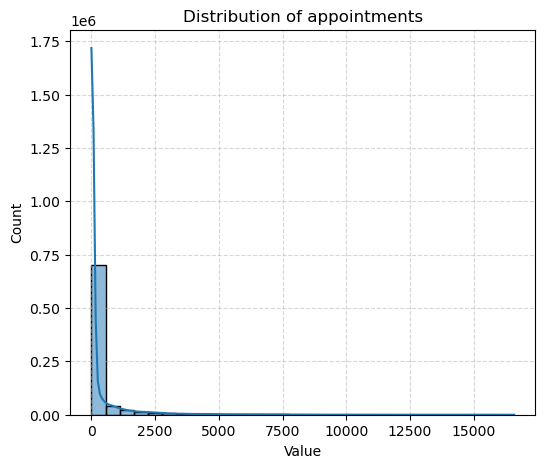

In [108]:
# distribution of data
plt.figure(figsize=(6,5))
sns.histplot(nc['count_of_appointments'], bins=30, kde=True)

plt.title('Distribution of appointments')
plt.xlabel('Value')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [153]:
# check for duplicates
nc.duplicated().sum()

0

In [154]:
# num of unique locations
nc['sub_icb_location_name'].nunique()

106

In [105]:
# number of service settings
num_service_setting = nc['service_setting'].nunique()
num_service_setting

5

In [106]:
# number of national categories
num_national_cat = nc['national_category'].nunique() 
num_national_cat 

18

In [107]:
# number of context types
num_context_type = nc['context_type'].nunique() 
num_context_type 

3

The NC dataset is structured to capture a comprehensive view of NHS appointment activity by category.
Number of appointments are analysed further according to three key categories: service setting, context type, and national category.

In [110]:
# convert date to datetime object
nc['appointment_month'] = pd.to_datetime(nc['appointment_month'], format='%Y-%m')

In [111]:
# number of appointments by location
location = nc.groupby(['sub_icb_location_name','appointment_month'])['count_of_appointments'].sum().sort_values(ascending = False).reset_index()
location 

,sub_icb_location_name,appointment_month,count_of_appointments
0,NHS North West London ICB - W2U3Z,2022-03-01,1232596
1,NHS North West London ICB - W2U3Z,2021-11-01,1204118
2,NHS North West London ICB - W2U3Z,2021-10-01,1180674
3,NHS North West London ICB - W2U3Z,2022-05-01,1163863
4,NHS North West London ICB - W2U3Z,2021-09-01,1144590
...,...,...,...
1161,NHS Greater Manchester ICB - 00V,2021-08-01,47565
1162,NHS Lancashire and South Cumbria ICB - 02G,2022-06-01,46965
1163,NHS Lancashire and South Cumbria ICB - 02G,2022-02-01,46684
1164,NHS Lancashire and South Cumbria ICB - 02G,2022-04-01,45216


In [112]:
# head: the most busiest location
location.head(10)

,sub_icb_location_name,appointment_month,count_of_appointments
0,NHS North West London ICB - W2U3Z,2022-03-01,1232596
1,NHS North West London ICB - W2U3Z,2021-11-01,1204118
2,NHS North West London ICB - W2U3Z,2021-10-01,1180674
3,NHS North West London ICB - W2U3Z,2022-05-01,1163863
4,NHS North West London ICB - W2U3Z,2021-09-01,1144590
5,NHS North West London ICB - W2U3Z,2022-06-01,1102597
6,NHS North West London ICB - W2U3Z,2022-02-01,1053468
7,NHS North West London ICB - W2U3Z,2022-01-01,1050517
8,NHS North West London ICB - W2U3Z,2021-12-01,1022195
9,NHS North West London ICB - W2U3Z,2022-04-01,1006387


In [113]:
# Tail: The least busiest lication
location.tail(10)

,sub_icb_location_name,appointment_month,count_of_appointments
1156,NHS Cheshire and Merseyside ICB - 01F,2022-04-01,49845
1157,NHS Cheshire and Merseyside ICB - 01T,2021-08-01,49754
1158,NHS Lancashire and South Cumbria ICB - 02G,2022-01-01,48419
1159,NHS Cheshire and Merseyside ICB - 01T,2022-04-01,47686
1160,NHS Lancashire and South Cumbria ICB - 02G,2021-12-01,47644
1161,NHS Greater Manchester ICB - 00V,2021-08-01,47565
1162,NHS Lancashire and South Cumbria ICB - 02G,2022-06-01,46965
1163,NHS Lancashire and South Cumbria ICB - 02G,2022-02-01,46684
1164,NHS Lancashire and South Cumbria ICB - 02G,2022-04-01,45216
1165,NHS Lancashire and South Cumbria ICB - 02G,2021-08-01,44685


In [114]:
# service settings
service_settings = nc.groupby(['service_setting','appointment_month'])['count_of_appointments'].sum().sort_values(ascending = False).reset_index()

service_settings['perc_appointments'] = (service_settings['count_of_appointments'] * 100 / \
                                             service_settings['count_of_appointments'].sum()).round(2)
service_settings

,service_setting,appointment_month,count_of_appointments,perc_appointments
0,General Practice,2021-11-01,27767889,9.38
1,General Practice,2021-10-01,27606171,9.32
2,General Practice,2022-03-01,27187368,9.18
3,General Practice,2021-09-01,25940821,8.76
4,General Practice,2022-05-01,25238620,8.53
5,General Practice,2022-06-01,23680374,8.00
6,General Practice,2022-01-01,23583053,7.97
7,General Practice,2022-02-01,23305934,7.87
8,General Practice,2021-12-01,23008818,7.77
9,General Practice,2022-04-01,21916791,7.40


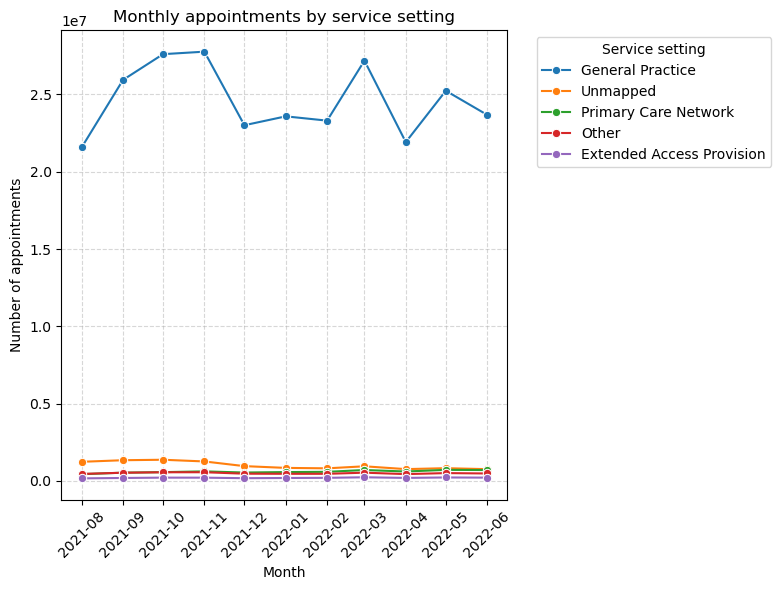

In [115]:
# plot service setting data
plt.figure(figsize=(8,6))
sns.lineplot(
    data=service_settings,
    x='appointment_month',
    y='count_of_appointments',
    hue='service_setting',
    marker='o'
)

plt.title('Monthly appointments by service setting')
plt.xlabel('Month')
plt.ylabel('Number of appointments')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Service setting', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Although the number of appointments fluctuates month to month, General Practice consistently has the highest number of recorded appointments among all service settings.

In [116]:
# context types
context_type =nc.groupby(['context_type', 'appointment_month'])['count_of_appointments'].sum().sort_values(ascending =False).reset_index()
context_type['perc_appointments'] = (context_type['count_of_appointments'] * 100 / \
                                             context_type['count_of_appointments'].sum()).round(2)

context_type

,context_type,appointment_month,count_of_appointments,perc_appointments
0,Care Related Encounter,2021-11-01,26282778,8.88
1,Care Related Encounter,2021-10-01,26125201,8.82
2,Care Related Encounter,2022-03-01,25928850,8.76
3,Care Related Encounter,2021-09-01,24404251,8.24
4,Care Related Encounter,2022-05-01,24101243,8.14
5,Care Related Encounter,2022-06-01,22621827,7.64
6,Care Related Encounter,2022-01-01,22441947,7.58
7,Care Related Encounter,2022-02-01,22211021,7.50
8,Care Related Encounter,2021-12-01,21798612,7.36
9,Care Related Encounter,2022-04-01,20904193,7.06


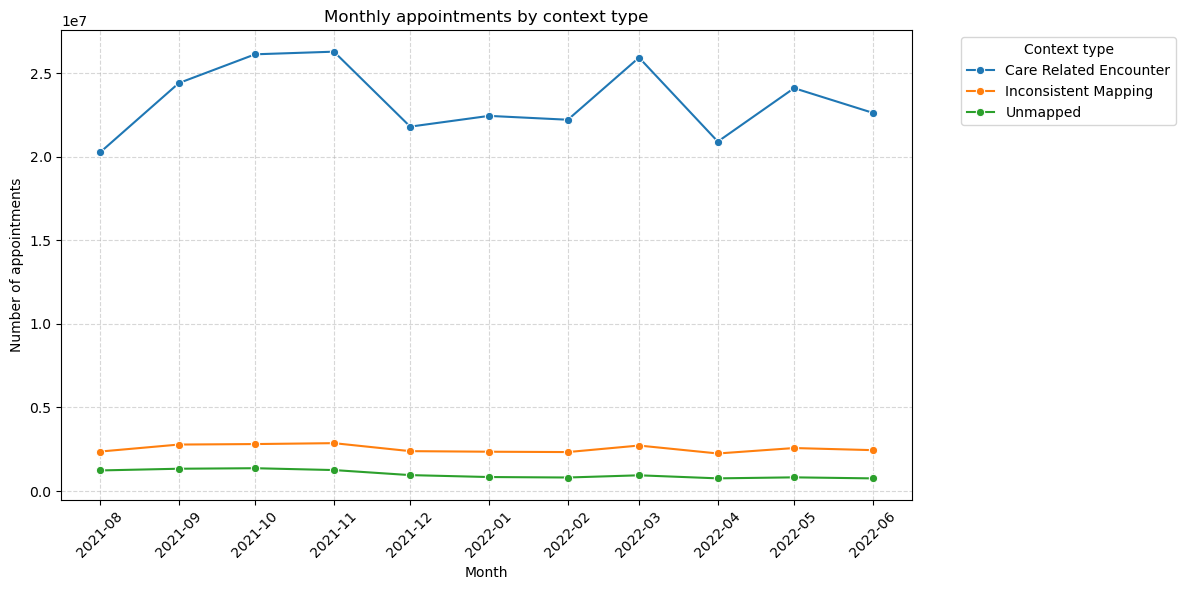

In [117]:
# Plot
plt.figure(figsize=(12,6))
sns.lineplot(
    data=context_type,
    x='appointment_month',
    y='count_of_appointments',
    hue='context_type',
    marker='o'
)

plt.title('Monthly appointments by context type')
plt.xlabel('Month')
plt.ylabel('Number of appointments')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Context type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Care-related encounters account for the highest number of appointments across the dataset. Inconsistent mapping and unmapped appointments follow, ranking among the lowest in terms of appointment counts.

In [118]:
# national categories
national_category = nc.groupby(['national_category','appointment_month'])['count_of_appointments'].sum().sort_values(ascending =False).reset_index()
national_category 

,national_category,appointment_month,count_of_appointments
0,General Consultation Routine,2022-03-01,10074249
1,General Consultation Routine,2021-11-01,9778682
2,General Consultation Routine,2022-05-01,9320538
3,General Consultation Routine,2021-10-01,9256788
4,General Consultation Routine,2021-09-01,9060243
...,...,...,...
193,Group Consultation and Group Education,2022-02-01,5397
194,Group Consultation and Group Education,2021-08-01,5161
195,Group Consultation and Group Education,2022-01-01,5108
196,Group Consultation and Group Education,2022-04-01,4921


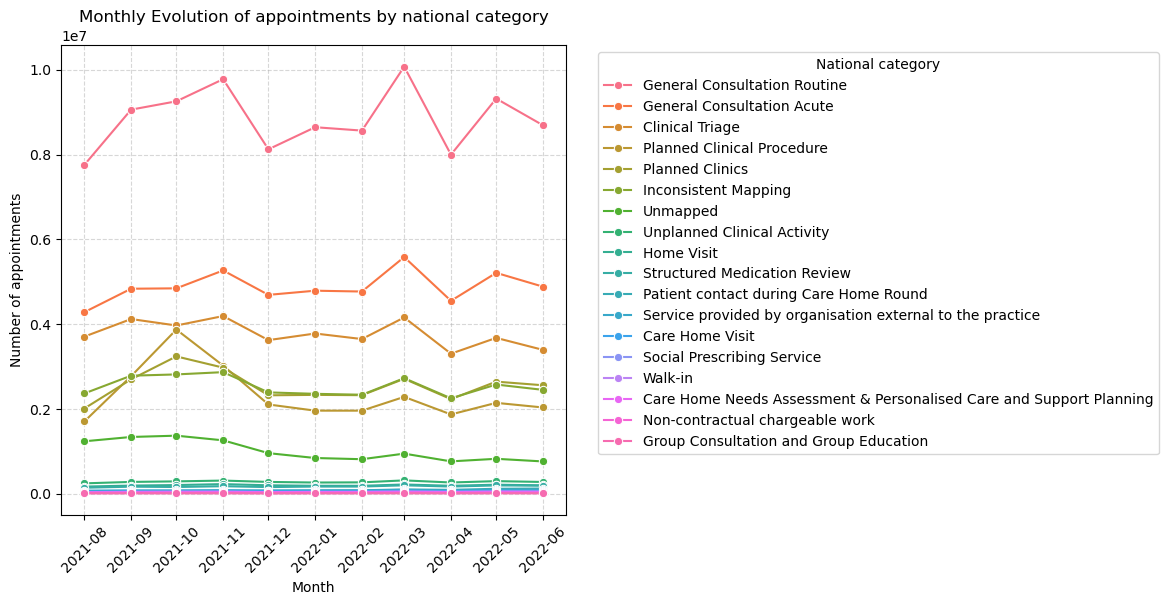

In [119]:
# plot national_category
plt.figure(figsize=(12,6))
sns.lineplot(
    data=national_category,
    x='appointment_month',
    y='count_of_appointments',
    hue='national_category',
    marker='o'
)

plt.title('Monthly Evolution of appointments by national category')
plt.xlabel('Month')
plt.ylabel('Number of appointments')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='National category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

General Consultation Routine consistently is having the highest number of appointments, ranging around 8 to 10 million monthly, indicating it is the primary service category. General Consultation Acute and Clinical Triage follow, maintaining steady appointment volumes but at substantially lower levels. Other categories like Planned Clinical Procedure and Planned Clinics show moderate appointment counts with minor fluctuations. Categories such as Inconsistent Mapping and Unmapped have noticeably lower appointment volumes, highlighting areas where data quality or categorisation may need attention. 

In [120]:
monthly_totals = nc.groupby('appointment_month')['count_of_appointments'].sum().reset_index()
monthly_totals

,appointment_month,count_of_appointments
0,2021-08-01,23852171
1,2021-09-01,28522501
2,2021-10-01,30303834
3,2021-11-01,30405070
4,2021-12-01,25140776
5,2022-01-01,25635474
6,2022-02-01,25355260
7,2022-03-01,29595038
8,2022-04-01,23913060
9,2022-05-01,27495508


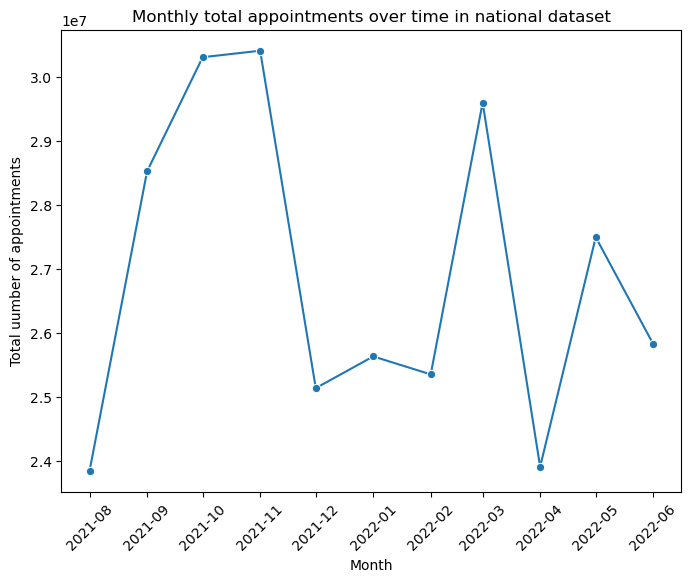

In [121]:
# plot
plt.figure(figsize=(8,6))
sns.lineplot(data=monthly_totals, x='appointment_month', y='count_of_appointments', marker='o')

plt.title('Monthly total appointments over time in national dataset')
plt.xlabel('Month')
plt.ylabel('Total uumber of appointments')
plt.xticks(rotation=45)
plt.show()

In [122]:
# MOM change
# Prepare x as numeric month index and y as counts
x = np.arange(len(monthly_totals))
y = monthly_totals['count_of_appointments'].values

# Fit linear trend
slope, intercept = np.polyfit(x, y, 1)

print(f"Estimated monthly change: {slope:.0f} appointments per month")

Estimated monthly change: -134603 appointments per month


The number of appointments is steadily declining month by month.
Over a year, this could add up to a loss of over 1.6 million appointments.
This decline could reflect changes in service demand, access issues, data recording changes, or external factors (e.g., policy shifts, pandemics).

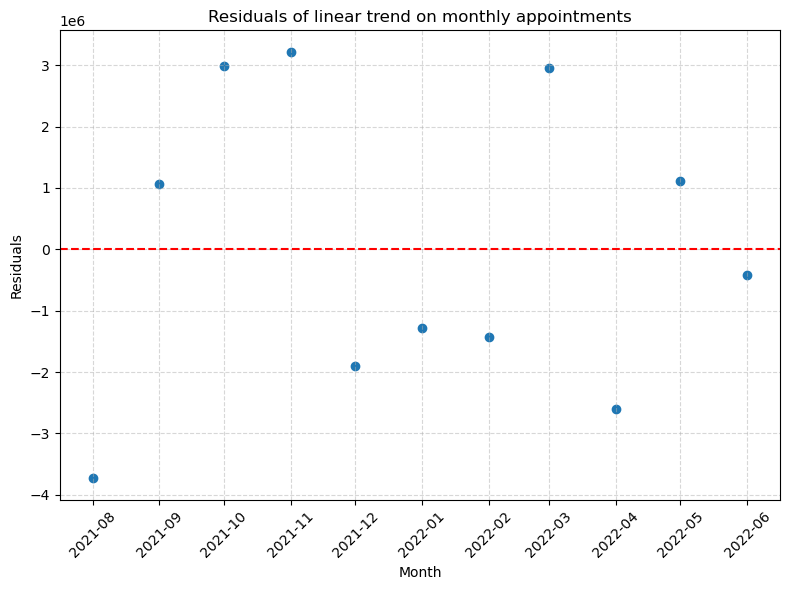

In [123]:

# Prepare x and y (from your monthly totals)
x = np.arange(len(monthly_totals))
y = monthly_totals['count_of_appointments'].values

# Fit linear trend
slope, intercept = np.polyfit(x, y, 1)
trend_line = slope * x + intercept

# Calculate residuals
residuals = y - trend_line

# Plot residuals
plt.figure(figsize=(8,6))
plt.scatter(monthly_totals['appointment_month'], residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals of linear trend on monthly appointments')
plt.xlabel('Month')
plt.ylabel('Residuals')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Further analysis of the busiest NHS Trust:'NHS North West London ICB - W2U3Z'

In [124]:
# filter out relavent field
filtered = nc[nc['sub_icb_location_name'] == 'NHS North West London ICB - W2U3Z']

In [125]:
# servive setting 
filtered.groupby('service_setting')['count_of_appointments'].sum().sort_values(ascending = False)

service_setting
General Practice             10432225
Unmapped                       904234
Other                          343642
Primary Care Network           240283
Extended Access Provision      222006
Name: count_of_appointments, dtype: int64

In [179]:
nc['count_of_appointments'].sum()

296046770

In [171]:
# context type
filtered.groupby('context_type')['count_of_appointments'].sum().sort_values(ascending = False)

context_type
Care Related Encounter    9988582
Inconsistent Mapping      1249574
Unmapped                   904234
Name: count_of_appointments, dtype: int64

In [126]:
# national category
filtered.groupby('national_category')['count_of_appointments'].sum().sort_values(ascending = False)

national_category
General Consultation Routine                                           3228687
Planned Clinics                                                        2340773
Clinical Triage                                                        1850292
General Consultation Acute                                             1548639
Inconsistent Mapping                                                   1249574
Unmapped                                                                904234
Planned Clinical Procedure                                              643581
Unplanned Clinical Activity                                             134933
Structured Medication Review                                             99412
Walk-in                                                                  48089
Home Visit                                                               33856
Service provided by organisation external to the practice                16733
Care Home Visit                   

NHS North West London ICB (W2U3Z) closely reflects national-level patterns in appointment activity. In both the ICB and national datasets, General Practice is the dominant service setting and Care Related Encounters form the largest context type, indicating a strong focus on direct patient care. Similarly, General Consultation Routine is the most common category, followed by Clinical Triage and Planned Clinics.

## Analysis of tweets related to healthcare 

In [127]:
# load df
tweets = pd.read_csv('tweets.csv')
tweets.head()

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,As Arkansas’ first Comprehensive Stroke Certif...,"{'hashtags': [{'text': 'Healthcare', 'indices'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 're...",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the...,"{'hashtags': [{'text': 'PremiseHealth', 'indic...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 're...",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long w...,"{'hashtags': [{'text': 'Healthcare', 'indices'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 're...",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies...,"{'hashtags': [{'text': 'NEW', 'indices': [20, ...",#NEW,"{'iso_language_code': 'en', 'result_type': 're...",5,0,False,False,en
4,1567582720460570625,ICYMI: Our recent blogs on Cybersecurity in Ac...,"{'hashtags': [{'text': 'blogs', 'indices': [18...","#blogs, #digitaltransformation, #cybersecurity...","{'iso_language_code': 'en', 'result_type': 're...",0,0,False,False,en


In [128]:
tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null   bool  
 9   tweet_lang               1174 non-null   object
dtypes: bool(2), int64(3), object(5)
memory usage: 75.8+ KB


In [160]:
tweets.columns

Index(['tweet_id', 'tweet_full_text', 'tweet_entities',
       'tweet_entities_hashtags', 'tweet_metadata', 'tweet_retweet_count',
       'tweet_favorite_count', 'tweet_favorited', 'tweet_retweeted',
       'tweet_lang'],
      dtype='object')

In [129]:
# count retweet
top_retweet_counts = tweets['tweet_retweet_count'].sort_values(ascending=False).unique()
top_retweet_counts

array([303, 208, 207, 169, 150, 107,  85,  79,  78,  76,  73,  72,  68,
        63,  62,  57,  54,  53,  49,  48,  44,  41,  40,  39,  37,  35,
        24,  23,  20,  19,  16,  15,  14,  13,  12,  11,  10,   9,   8,
         7,   6,   5,   4,   3,   2,   1,   0], dtype=int64)

In [163]:
tweets.isna().sum()

tweet_id                     0
tweet_full_text              0
tweet_entities               0
tweet_entities_hashtags    167
tweet_metadata               0
tweet_retweet_count          0
tweet_favorite_count         0
tweet_favorited              0
tweet_retweeted              0
tweet_lang                   0
dtype: int64

In [130]:
# engagement analysis
#Most liked/retweeted tweets and Average engagement per tweet

tweets[['tweet_retweet_count','tweet_favorite_count']].describe()

,tweet_retweet_count,tweet_favorite_count
count,1174.000000,1174.00000
mean,8.629472,0.37138
std,29.784675,2.04470
min,0.000000,0.00000
25%,0.000000,0.00000
50%,1.000000,0.00000
75%,3.000000,0.00000
max,303.000000,42.00000


The distribution of tweet retweets is highly skewed toward low engagement. The 25th and 75th quartiles are 0 and 3, indicating that most tweets receive little to no traction. The median is just 1 retweet, indicating that typical tweets get minimal interaction. Although the mean is higher at around 8.6 retweets per tweet, this is because, a small number of viral posts having the maximum reaching 303 retweets.

In [169]:
# retweets
top_retweet_counts = tweets['tweet_retweet_count'].sort_values(ascending=False).unique()
top_retweet_counts

array([303, 208, 207, 169, 150, 107,  85,  79,  78,  76,  73,  72,  68,
        63,  62,  57,  54,  53,  49,  48,  44,  41,  40,  39,  37,  35,
        24,  23,  20,  19,  16,  15,  14,  13,  12,  11,  10,   9,   8,
         7,   6,   5,   4,   3,   2,   1,   0], dtype=int64)

In [136]:
# top re-tweet
top_retweet = tweets[['tweet_full_text','tweet_retweet_count']].sort_values(by= 'tweet_retweet_count',ascending=False)
top_retweet 

,tweet_full_text,tweet_retweet_count
263,RT @UltimaLionsDen: Temitope is looking to boo...,303
1139,"RT @khaleejtimes: .@BurjeelHoldings, a private...",208
985,"RT @khaleejtimes: .@BurjeelHoldings, a private...",208
330,"RT @khaleejtimes: .@BurjeelHoldings, a private...",208
595,"RT @khaleejtimes: .@BurjeelHoldings, a private...",208
...,...,...
565,Do you enjoy helping patients reach their goal...,0
566,Medicare Advantage lobby rebuts senator’s inqu...,0
569,"Interested in a job in #Hillsboro, TX? This co...",0
570,@CP24 Privatization erodes universal #healthca...,0


In [138]:
# segment tweets by top 5%(95q) as viral tweets
viral = tweets[tweets['tweet_retweet_count'] > tweets['tweet_retweet_count'].quantile(0.95)]
non_viral = tweets[tweets['tweet_retweet_count'] == 0]

In [139]:
# extract most top 20 common words in top 5% of tweets
from collections import Counter

top_text = " ".join(viral['tweet_full_text'].astype(str))
words = Counter(top_text.lower().split())
words.most_common(20)

[('rt', 59),
 ('the', 34),
 ('to', 31),
 ('a', 25),
 ('with', 23),
 ('in', 23),
 ('is', 23),
 ('has', 21),
 ('as', 18),
 ('#healthcare', 18),
 ('@khaleejtimes:', 15),
 ('.@burjeelholdings,', 15),
 ('private', 15),
 ('healthcare', 15),
 ('services', 15),
 ('provider,', 15),
 ('partnered', 15),
 ('superstar', 15),
 ('@iamsrk', 15),
 ('its', 15)]

In [ ]:
The most shared (retweeted) content is not dominated by medical discussion.
Health-related terms like “#healthcare”, “healthcare”, and “services” appear, but they are secondary to other content.

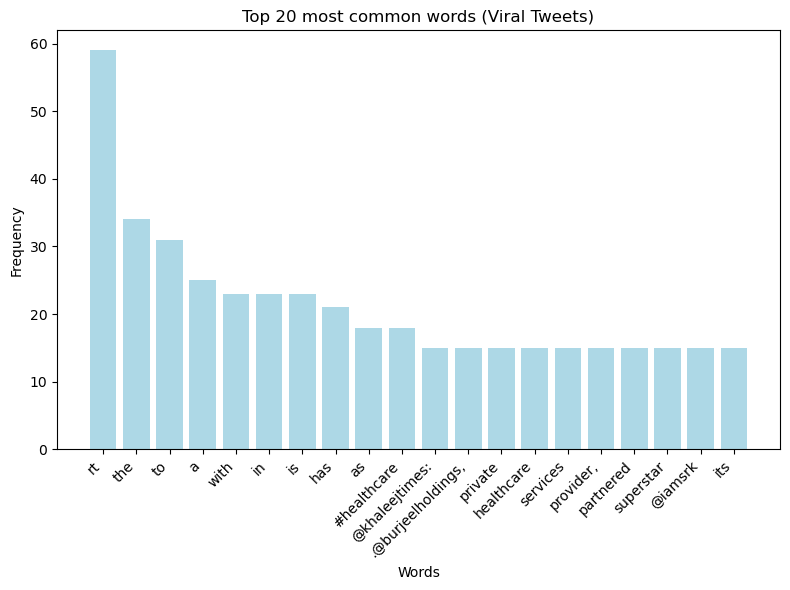

In [145]:
# get top 20
common_words = words.most_common(20)
word_labels, word_counts = zip(*common_words)
# plot
plt.figure(figsize=(8,6))
plt.bar(word_labels, word_counts,color = 'lightblue')

plt.title("Top 20 most common words (Viral Tweets)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [173]:
# language used: all in English
tweets['tweet_lang'].unique()

array(['en'], dtype=object)

In [131]:
import ast
from collections import Counter
import re

# function to extract hashtags
def parse_hashtags(x):
    x = str(x)
    hashtags = []
    if x.startswith('[') and x.endswith(']'):
        try:
            hashtags = [tag.lower() for tag in ast.literal_eval(x)]
        except:
            hashtags = []
    else:
        hashtags = re.findall(r"#\w+", x.lower())
    return hashtags

# flatten all hashtags
all_hashtags = [tag for row in tweets['tweet_entities_hashtags'].dropna() for tag in parse_hashtags(row)]

# count
hashtag_counts = Counter(all_hashtags)

hashtag_counts 

Counter({'#healthcare': 844,
         '#health': 86,
         '#ai': 47,
         '#medicine': 42,
         '#job': 38,
         '#medical': 35,
         '#strategy': 31,
         '#digitalhealth': 31,
         '#pharmaceutical': 28,
         '#medtwitter': 27,
         '#competitiveintelligence': 25,
         '#marketing': 25,
         '#biotech': 25,
         '#pharma': 25,
         '#meded': 24,
         '#telehealth': 22,
         '#hiring': 21,
         '#tipsfornewdocs': 21,
         '#covid': 21,
         '#vaccine': 18,
         '#technology': 18,
         '#healthtech': 18,
         '#machinelearning': 18,
         '#news': 17,
         '#medicare': 17,
         '#coronavirus': 16,
         '#competitivemarketing': 16,
         '#womeninmedicine': 16,
         '#covid19': 15,
         '#wellness': 15,
         '#nursing': 14,
         '#telemedicine': 14,
         '#science': 14,
         '#education': 14,
         '#tech': 14,
         '#doctorofveterinarymedicine': 14,
     

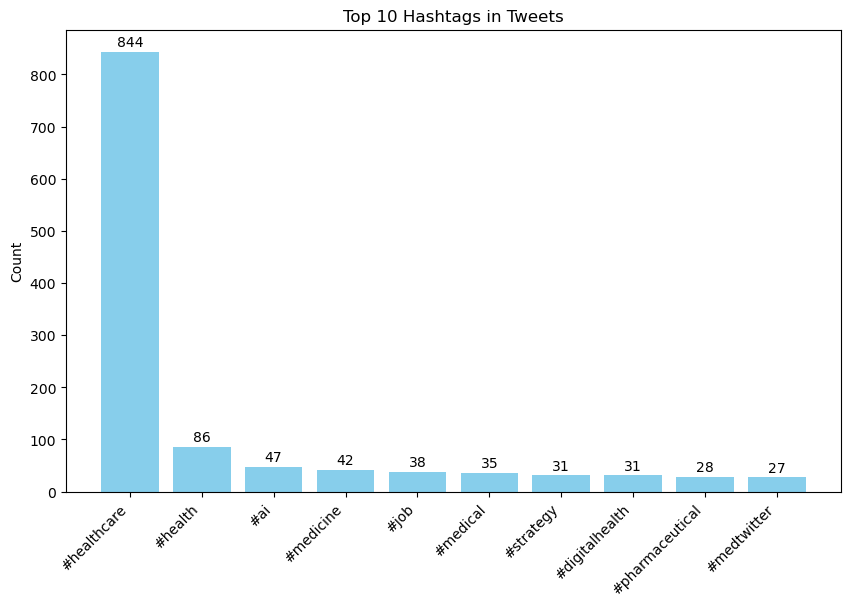

In [132]:

# get top 10
top_hashtags = hashtag_counts.most_common(10)
tags, counts = zip(*top_hashtags)

plt.figure(figsize=(10,6))
bars = plt.bar(tags, counts, color='skyblue')

# annotate numbers on top of each bar
for bar, count in zip(bars, counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(count), ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Hashtags in Tweets")
plt.ylabel("Count")
plt.show()

Most hashtags are health-focused,  #healthcare is appearing 844 times, far more than any other hashtag. 
Frequent Themes:
Healthcare & medicine
Jobs & education
COVID & vaccines
Most hashtags occur less than 50 times, indicating a few highly popular hashtags and many niche tags.

### Word frequency counts
Purpose: see the most common words in your tweets.

Steps:
Clean the text: remove URLs, mentions, punctuation, stopwords.
Tokenize words.
Count frequencies.

In [133]:
from collections import Counter
import re
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# clean and tokenize
def clean_text(text):
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)     # remove mentions
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation
    text = text.lower()
    words = [w for w in text.split() if w not in stop_words]
    return words

tweet_words = tweets['tweet_full_text'].apply(clean_text)
all_words = [word for sublist in tweet_words for word in sublist]

# count frequency
word_counts = Counter(all_words)
word_counts.most_common(20)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lakma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('healthcare', 976),
 ('rt', 517),
 ('health', 248),
 ('care', 123),
 ('amp', 110),
 ('job', 97),
 ('new', 93),
 ('us', 87),
 ('medical', 76),
 ('learn', 66),
 ('covid', 59),
 ('hiring', 51),
 ('ai', 51),
 ('medicine', 51),
 ('data', 49),
 ('join', 48),
 ('patients', 48),
 ('help', 47),
 ('apply', 45),
 ('system', 44)]

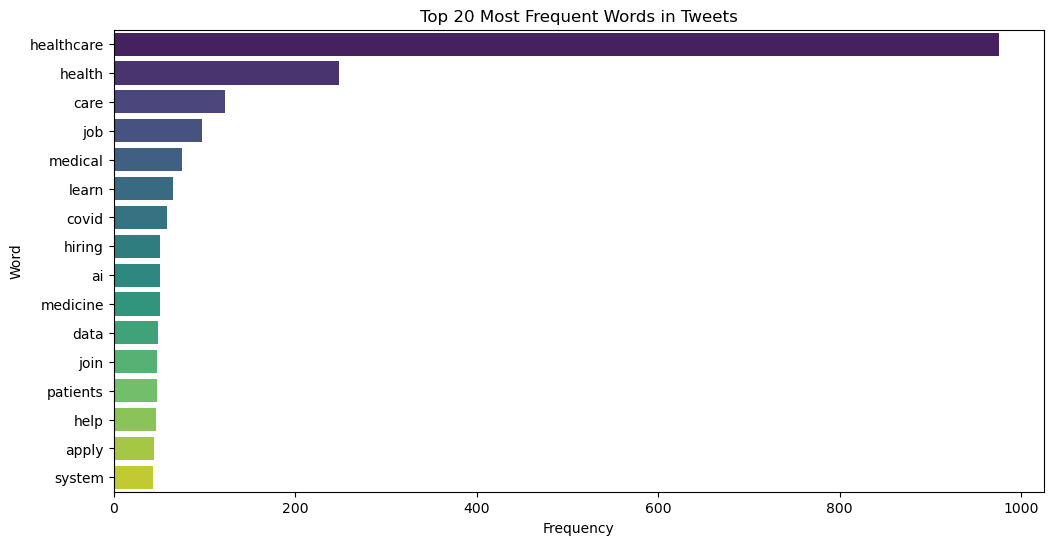

In [189]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get top 20 words from Counter
top_20 = word_counts.most_common(20)

# Convert to DataFrame
df_top20 = pd.DataFrame(top_20, columns=['word', 'count'])

# Optional: remove common Twitter tokens
df_top20 = df_top20[~df_top20['word'].isin(['rt','amp','us','new'])]

# Plot horizontal bar chart
plt.figure(figsize=(12,6))
sns.barplot(data=df_top20, x='count', y='word', palette='viridis')
plt.title('Top 20 Most Frequent Words in Tweets')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

The tweets are mainly focused on healthcare-related topics such as health, jobs, AI, and medical updates, with job and recruitment content appearing frequently.

In [134]:
# sentiment analysis
#understand positive, negative, or neutral tone.

from textblob import TextBlob

# get sentiment polarity (-1 to 1)
tweets['sentiment'] = tweets['tweet_full_text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# categorize
tweets['sentiment_category'] = tweets['sentiment'].apply(lambda x: 'positive' if x>0 else ('negative' if x<0 else 'neutral'))

# summary
tweets['sentiment_category'].value_counts()

sentiment_category
positive    618
neutral     449
negative    107
Name: count, dtype: int64

In [ ]:
The positive sentiment is likely associated with these tweets:

Healthcare topics – words like healthcare, health, care, medical, patients appear a lot, so positive tweets could be about success stories, innovations, or helpful healthcare information.
Job postings / hiring – words like job, hiring, apply, join, learn suggest that positive sentiment could reflect opportunities or encouragement to apply.
COVID or medical updates – tweets may contain helpful information, guidance, or recovery stories, which are classified as positive.
AI and data in healthcare – mentions of technology improving healthcare could be framed optimistically.